# Airbnb Price Prediction

## Objectif
Prédire le **prix de nuit** de logements Airbnb à partir de leurs caractéristiques.

## Données
- **Train** : 22 235 annonces avec le prix connu
- **Test** : 51 881 annonces dont on doit prédire le prix
- Variables disponibles : type de logement, ville, quartier, équipements, infos hôte, avis...

## Étapes du projet
1. **Explorer les données** : comprendre ce qui influence le prix
2. **Préparer les features** : transformer les colonnes brutes en nombres utilisables
3. **Encoder les catégories** : convertir les textes en valeurs numériques
4. **Entraîner un modèle** : LightGBM avec validation croisée
5. **Analyser les résultats** : vérifier que le modèle est cohérent

> La variable cible est `log_price` (le logarithme du prix).

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import contextily as ctx
from sklearn.model_selection import KFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error
import re
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

try:
    import lightgbm as lgb
    USE_LGBM = True
    print(f"LightGBM {lgb.__version__} disponible")
except ImportError:
    USE_LGBM = False
    print("LightGBM non disponible, fallback GradientBoostingRegressor")

plt.rcParams['figure.figsize'] = (12, 5)
pd.set_option('display.max_columns', 50)
SEED = 42
np.random.seed(SEED)

LightGBM 4.6.0 disponible


## 1. Chargement des données

In [90]:
train = pd.read_csv('airbnb_train.csv')
test  = pd.read_csv('airbnb_test.csv')

# La 1ère colonne du test est sans nom (c'est l'id)
test.rename(columns={test.columns[0]: 'id'}, inplace=True)

print(f"Train : {train.shape[0]:,} lignes x {train.shape[1]} colonnes")
print(f"Test  : {test.shape[0]:,} lignes x {test.shape[1]} colonnes")
train.head(3)

Train : 22,234 lignes x 28 colonnes
Test  : 51,877 lignes x 27 colonnes


,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,zipcode,bedrooms,beds
0,5708593,4.317488,House,Private room,"{TV,""Wireless Internet"",Kitchen,""Free parking ...",3,1.0,Real Bed,flexible,False,LA,Large bright airy room with 2 balconies and Ja...,NaN,t,f,NaN,2015-12-12,t,NaN,33.782712,-118.134410,Island style Spa Studio,Long Beach,0,NaN,90804,0.0,2.0
1,14483613,4.007333,House,Private room,"{""Wireless Internet"",""Air conditioning"",Kitche...",4,2.0,Real Bed,strict,False,NYC,Private room for rent in a six bedroom apt wit...,2017-05-07,t,t,100%,2016-11-04,t,2017-09-17,40.705468,-73.909439,"Beautiful and Simple Room W/2 Beds, 25 Mins to...",Ridgewood,38,86.0,11385,1.0,2.0
2,10412649,7.090077,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",6,2.0,Real Bed,flexible,False,DC,"14th st corridor 2br/2ba condo, secure boutiqu...",NaN,t,f,NaN,2016-12-11,t,NaN,38.917537,-77.031651,2br/2ba luxury condo perfect for infant / toddler,U Street Corridor,0,NaN,20009,2.0,2.0


## 2. Exploration des données (EDA)

In [91]:
# Valeurs manquantes
def missing_report(df, name):
    m = (df.isnull() | (df == '')).sum()
    m = m[m > 0].sort_values(ascending=False)
    pct = (m / len(df) * 100).round(1)
    print(f"\n--- {name} ---")
    print(pd.DataFrame({'manquants': m, '%': pct}).to_string())

missing_report(train, 'Train')


--- Train ---
                        manquants     %
host_response_rate           5475  24.6
review_scores_rating         4978  22.4
first_review                 4725  21.3
last_review                  4716  21.2
neighbourhood                2086   9.4
zipcode                       303   1.4
host_has_profile_pic           56   0.3
host_identity_verified         56   0.3
host_since                     56   0.3
bathrooms                      51   0.2
beds                           35   0.2
bedrooms                       26   0.1


### Observations : valeurs manquantes

Certaines colonnes ont beaucoup de valeurs manquantes :
- `host_response_rate` : environ 40% des hôtes ne renseignent pas ce champ
- `review_scores_rating`, `first_review`, `last_review` : vides pour les nouvelles annonces sans avis

**Ce qu'on va faire** : créer une colonne supplémentaire pour indiquer si la date est absente (c'est une info utile), et remplacer les valeurs numériques manquantes par la médiane.

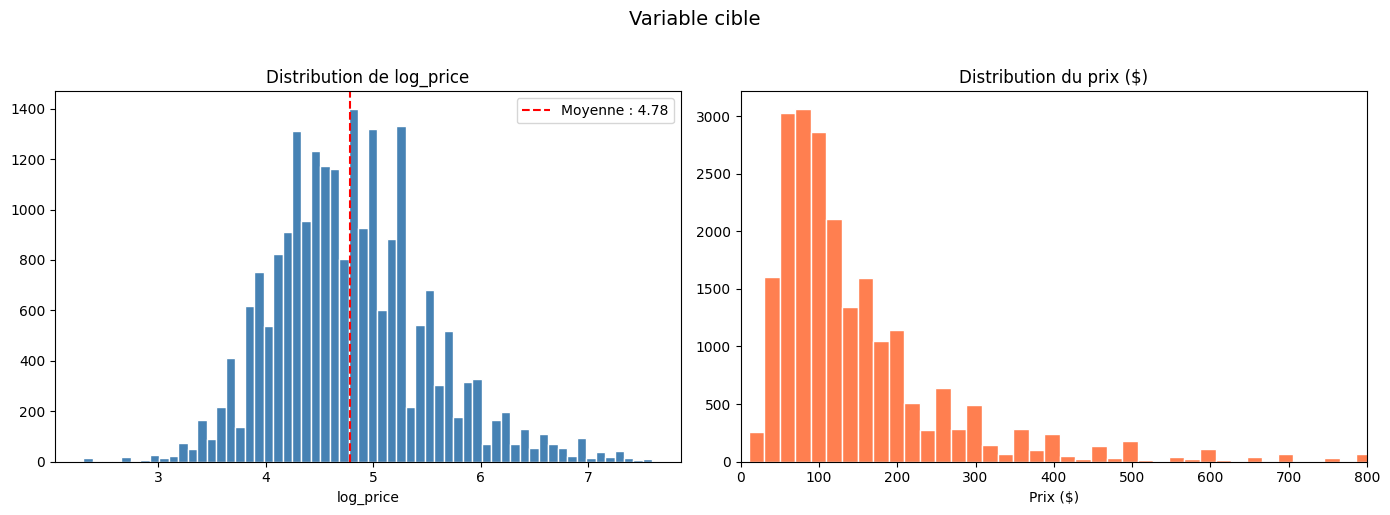

min=2.30  max=7.60  mean=4.78  std=0.72


In [92]:
# Distribution de la variable cible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(train['log_price'], bins=60, color='steelblue', edgecolor='white', lw=0.5)
axes[0].axvline(train['log_price'].mean(), color='red', ls='--',
                label=f"Moyenne : {train['log_price'].mean():.2f}")
axes[0].set_title('Distribution de log_price'); axes[0].set_xlabel('log_price')
axes[0].legend()

axes[1].hist(np.exp(train['log_price']), bins=100, color='coral', edgecolor='white', lw=0.5)
axes[1].set_xlim(0, 800); axes[1].set_title('Distribution du prix ($)')
axes[1].set_xlabel('Prix ($)')

plt.suptitle('Variable cible', fontsize=14, y=1.02)
plt.tight_layout(); plt.show()
print(f"min={train['log_price'].min():.2f}  max={train['log_price'].max():.2f}  "
      f"mean={train['log_price'].mean():.2f}  std={train['log_price'].std():.2f}")

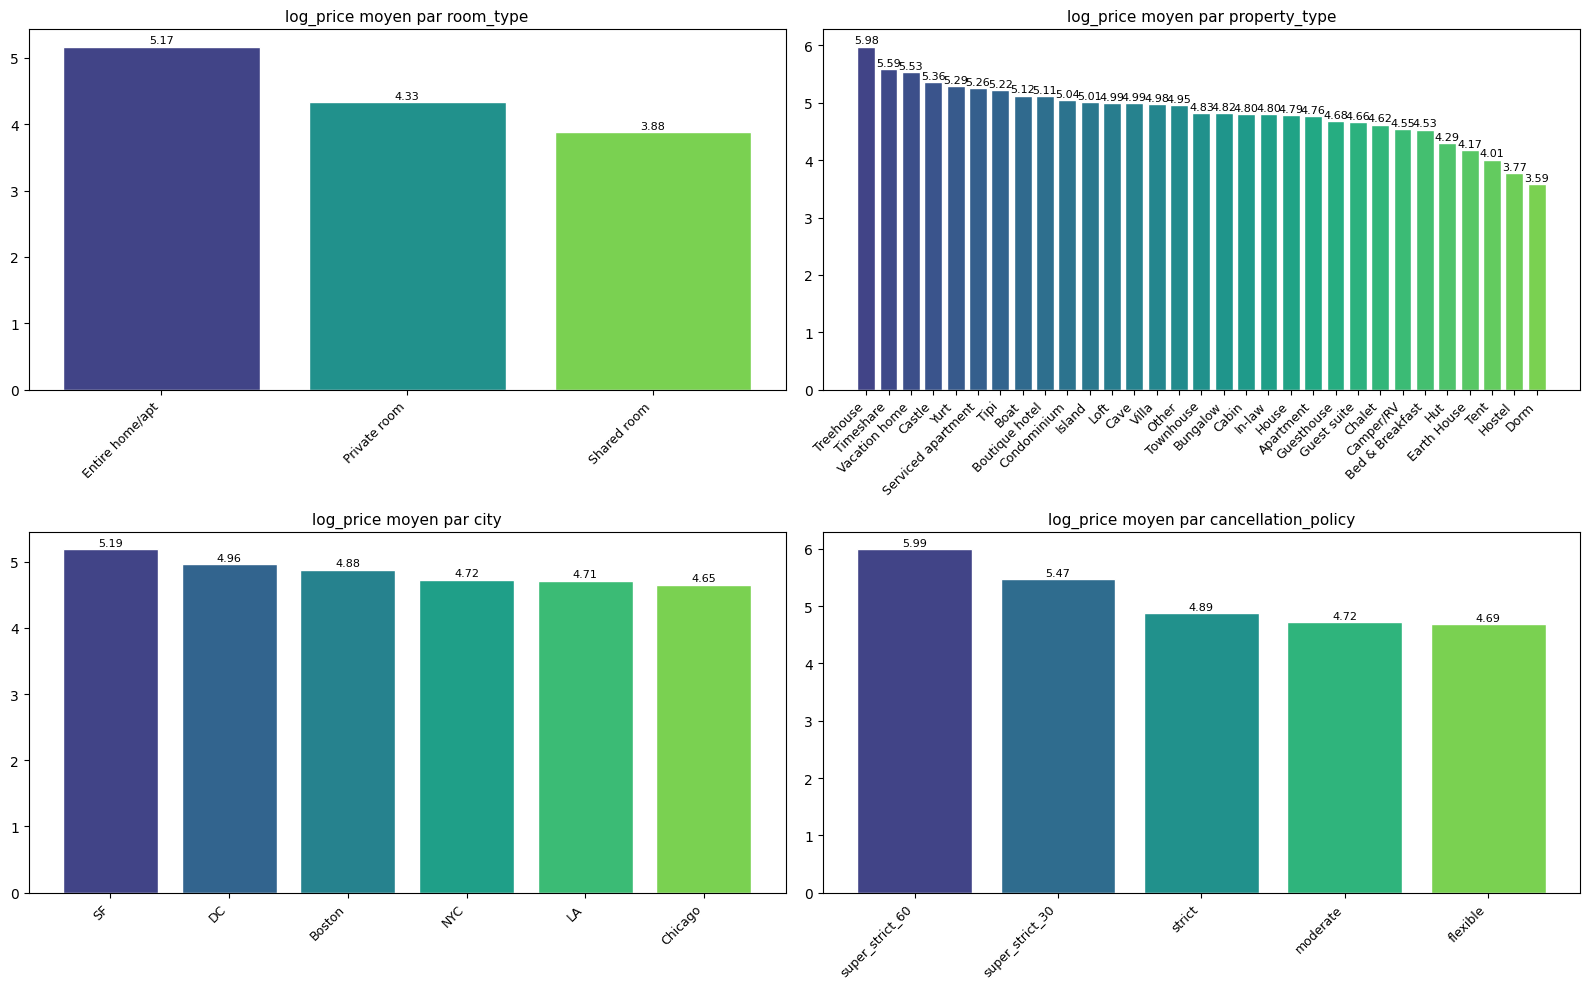

In [93]:
# Prix moyen par catégorie
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), ['room_type','property_type','city','cancellation_policy']):
    means = train.groupby(col)['log_price'].mean().sort_values(ascending=False)
    colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(means)))
    bars = ax.bar(range(len(means)), means.values, color=colors, edgecolor='white')
    ax.set_xticks(range(len(means)))
    ax.set_xticklabels(means.index, rotation=45, ha='right', fontsize=9)
    ax.set_title(f'log_price moyen par {col}', fontsize=11)
    for bar, val in zip(bars, means.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()+0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=8)
plt.tight_layout(); plt.show()

### Observations : prix par catégorie

- Louer un logement entier coûte environ 2x plus cher qu'une chambre privée
- Bateaux, châteaux et villas ont les prix les plus élevés
- San Francisco et New York sont les villes les plus chères
- Les hôtes avec des règles d'annulation strictes proposent souvent des logements haut de gamme

Ces variables ont donc un vrai impact sur le prix et seront utiles au modèle.

In [94]:
# Corrélations numériques
num_cols = ['accommodates','bathrooms','bedrooms','beds','number_of_reviews','review_scores_rating']
tmp = train[num_cols + ['log_price']].copy()
for c in num_cols:
    tmp[c] = pd.to_numeric(tmp[c], errors='coerce')
corr = tmp.corr()['log_price'].drop('log_price').sort_values(key=abs, ascending=False)
print("Corrélations avec log_price:")
print(corr.round(3))

Corrélations avec log_price:
accommodates            0.565
bedrooms                0.473
beds                    0.435
bathrooms               0.369
review_scores_rating    0.092
number_of_reviews      -0.039
Name: log_price, dtype: float64


### Observations : corrélations numériques

- Plus le logement est grand (voyageurs, chambres, salles de bain), plus il est cher
- Les logements avec beaucoup d'avis sont souvent moins chers (les logements abordables tournent davantage)
- La note des avis a peu d'effet direct sur le prix

La taille du logement est donc le principal facteur numérique.

## 2.2 Visualisations Avancées

Pour approfondir la compréhension des données :
- **Carte géographique** des annonces colorée par prix (rouge = cher, vert = pas cher)
- **Heatmap de corrélation** entre toutes les variables numériques
- **Boxplot** comparant la distribution des prix par ville
- **Impact des amenities** : quels équipements font monter ou baisser le prix ?
- **Violin plot** par type de logement + courbe prix / capacité d'accueil

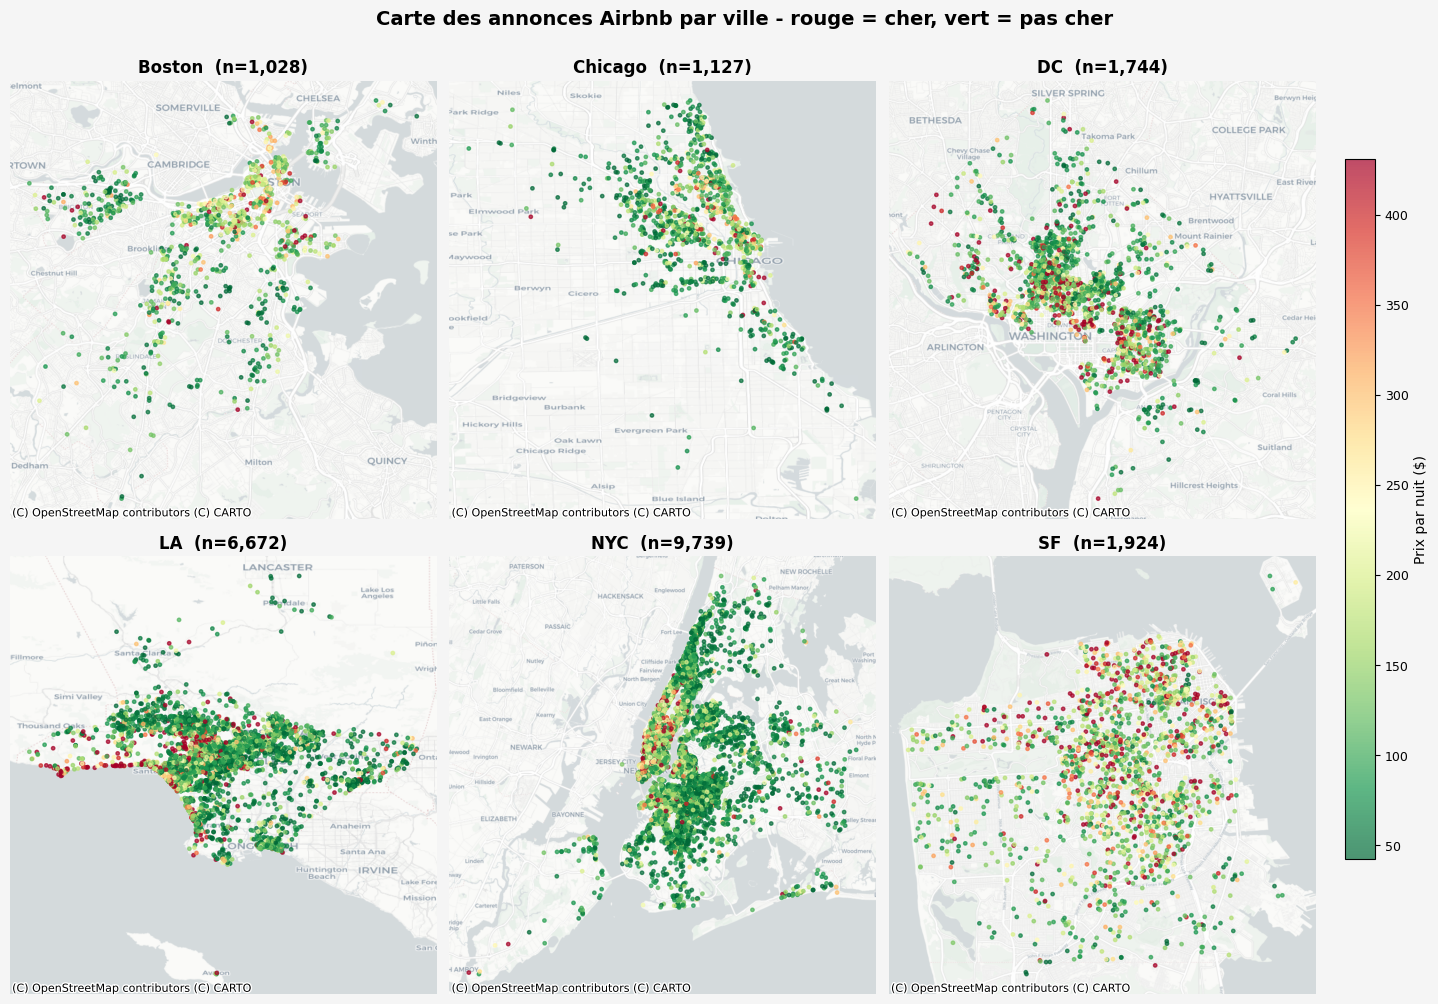

Prix median : $110/nuit  |  Prix max : $1999/nuit


In [95]:
# Cartes geographiques des prix par ville (rouge = cher, vert = pas cher)
import contextily as ctx

prices_all = np.exp(train['log_price'])
p5, p95 = np.percentile(prices_all, 5), np.percentile(prices_all, 95)

cities = sorted(train['city'].dropna().unique())
ncols = 3
nrows = int(np.ceil(len(cities) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 5 * nrows))
axes = np.atleast_1d(axes).ravel()

R = 6378137.0

def to_mercator(lon, lat):
    lon = pd.to_numeric(lon, errors='coerce').values.astype(float)
    lat = pd.to_numeric(lat, errors='coerce').values.astype(float)
    x = np.radians(lon) * R
    y = np.log(np.tan(np.pi / 4 + np.radians(lat) / 2)) * R
    return x, y

sc = None
for ax, city in zip(axes, cities):
    sub = train[train['city'] == city]
    prices = np.exp(sub['log_price']).clip(p5, p95)

    x, y = to_mercator(sub['longitude'], sub['latitude'])
    valid = ~(np.isnan(x) | np.isnan(y))

    sc = ax.scatter(x[valid], y[valid], c=prices.values[valid],
                    cmap='RdYlGn_r', s=6, alpha=0.7, vmin=p5, vmax=p95)

    ctx.add_basemap(ax, crs='EPSG:3857',
                    source=ctx.providers.CartoDB.Positron, zoom='auto')

    ax.set_title(f'{city}  (n={len(sub):,})', fontsize=12, fontweight="bold")
    ax.set_axis_off()

for ax in axes[len(cities):]:
    ax.axis('off')

fig.suptitle('Carte des annonces Airbnb par ville - rouge = cher, vert = pas cher',
             fontsize=14, fontweight="bold", y=1.00)
fig.patch.set_facecolor('#f5f5f5')

# tight_layout d'abord, puis espace reserve a droite pour la colorbar
plt.tight_layout()
plt.subplots_adjust(right=0.88)
cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.70])
cbar = fig.colorbar(sc, cax=cbar_ax, label='Prix par nuit ($)')
cbar.ax.tick_params(labelsize=9)

plt.show()
print(f'Prix median : ${np.median(prices_all):.0f}/nuit  |  Prix max : ${prices_all.max():.0f}/nuit')

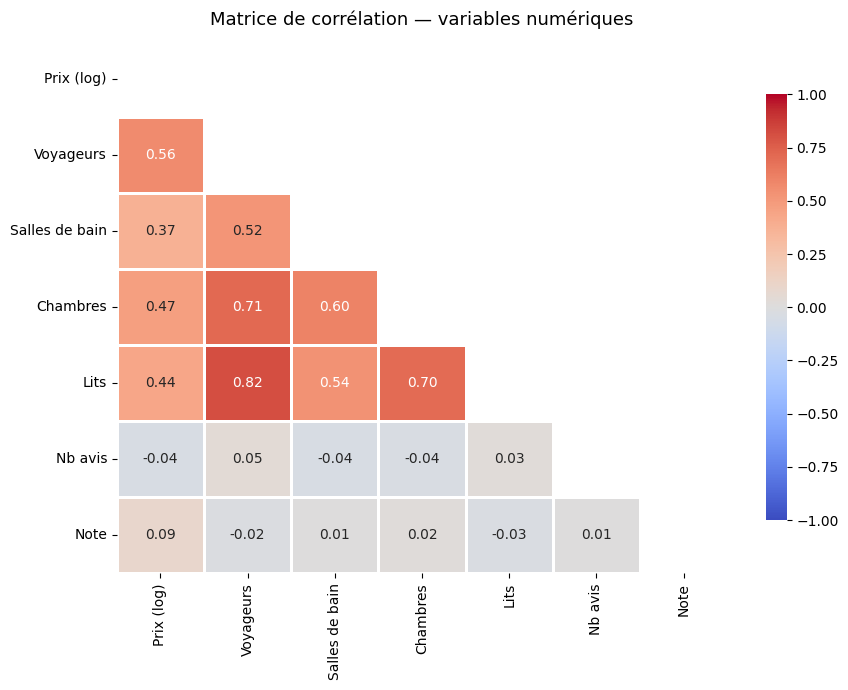

In [96]:
# ── Heatmap de corrélation ────────────────────────────────────────────────────
num_cols_viz = ['log_price', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
                'number_of_reviews', 'review_scores_rating']
labels_fr = {'log_price': 'Prix (log)', 'accommodates': 'Voyageurs',
             'bathrooms': 'Salles de bain', 'bedrooms': 'Chambres', 'beds': 'Lits',
             'number_of_reviews': 'Nb avis', 'review_scores_rating': 'Note'}

tmp_corr = train[num_cols_viz].copy()
for c in num_cols_viz:
    tmp_corr[c] = pd.to_numeric(tmp_corr[c], errors='coerce')
tmp_corr.rename(columns=labels_fr, inplace=True)

corr = tmp_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.8, linecolor='white',
            annot_kws={'size': 10}, ax=ax, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax.set_title('Matrice de corrélation : variables numériques', fontsize=13, pad=12)
plt.tight_layout()
plt.show()

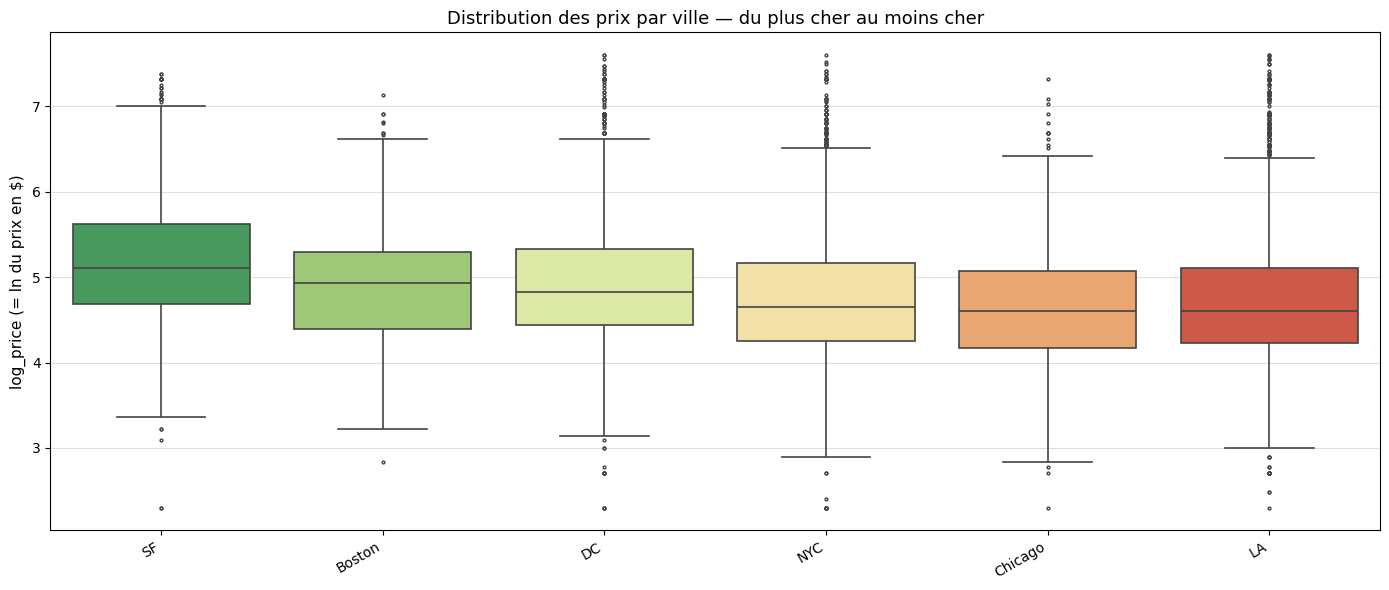

In [97]:
# ── Boxplot des prix par ville ────────────────────────────────────────────────
city_order = (train.groupby('city')['log_price']
              .median().sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(14, 6))
palette_cities = sns.color_palette('RdYlGn_r', n_colors=len(city_order))
sns.boxplot(data=train, x='city', y='log_price', order=city_order,
            palette=palette_cities, linewidth=1.2, fliersize=2, ax=ax)
ax.set_xticklabels(city_order, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('log_price (= ln du prix en $)', fontsize=11)
ax.set_xlabel('')
ax.set_title('Distribution des prix par ville, du plus cher au moins cher', fontsize=13)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

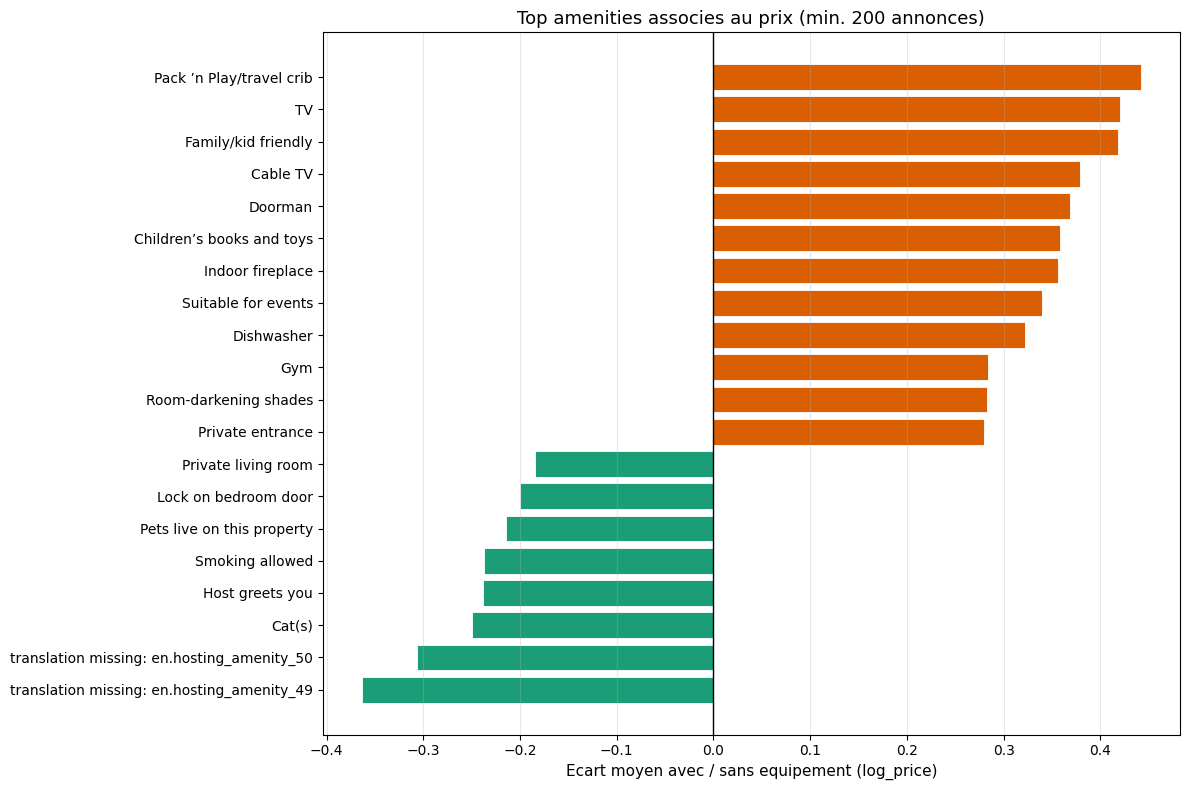

Amenities analysees : 72 avec au moins 200 annonces
                  amenity  count  share  delta_vs_without
 Pack ’n Play/travel crib    347  0.016             0.442
                       TV  15809  0.711             0.421
      Family/kid friendly  11240  0.506             0.418
                 Cable TV   7348  0.330             0.379
                  Doorman   1459  0.066             0.369
Children’s books and toys    352  0.016             0.358
         Indoor fireplace   2779  0.125             0.356
      Suitable for events   1304  0.059             0.339
               Dishwasher    706  0.032             0.323
                      Gym   2257  0.102             0.284


In [98]:
# -- Top amenities associes au prix ------------------------------------------
def _parse_am(s):
    if pd.isna(s) or s == '':
        return []
    items = []
    for item in str(s).strip('{}').split(','):
        item = item.strip().strip('"').strip()
        if item:
            items.append(item)
    return items

am_lists = train['amenities'].apply(_parse_am)
am_counts = Counter(am for items in am_lists for am in items)
global_mean_price = train['log_price'].mean()

amenity_rows = []
for amenity, count in am_counts.items():
    if count < 200:
        continue
    has_amenity = am_lists.apply(lambda items, a=amenity: a in items)
    avg_with = train.loc[has_amenity, 'log_price'].mean()
    avg_without = train.loc[~has_amenity, 'log_price'].mean()
    amenity_rows.append({
        'amenity': amenity,
        'count': count,
        'share': count / len(train),
        'avg_log_price': avg_with,
        'delta_vs_global': avg_with - global_mean_price,
        'delta_vs_without': avg_with - avg_without,
    })

am_df = pd.DataFrame(amenity_rows)
top_up = am_df.sort_values('delta_vs_without', ascending=False).head(12)
top_down = am_df.sort_values('delta_vs_without').head(8)
plot_df = pd.concat([top_down, top_up]).sort_values('delta_vs_without')
colors = np.where(plot_df['delta_vs_without'] >= 0, '#d95f02', '#1b9e77')

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(plot_df['amenity'], plot_df['delta_vs_without'],
        color=colors, edgecolor='white', linewidth=0.6)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Ecart moyen avec / sans equipement (log_price)', fontsize=11)
ax.set_title('Top amenities associes au prix (min. 200 annonces)', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Amenities analysees : {len(am_df)} avec au moins 200 annonces")
print(am_df.sort_values('delta_vs_without', ascending=False)
          [['amenity','count','share','delta_vs_without']]
          .head(10).round({'share': 3, 'delta_vs_without': 3}).to_string(index=False))

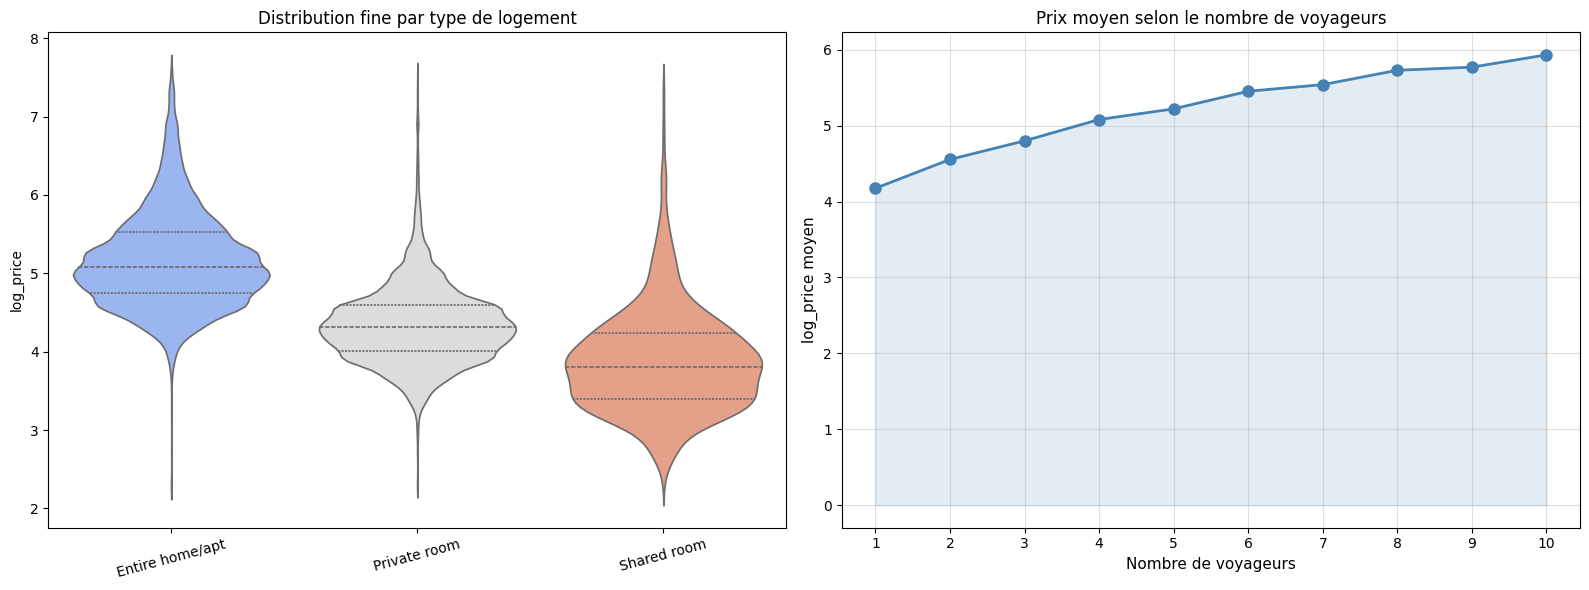

In [99]:
# ── Violin + courbe prix / voyageurs ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

room_order = (train.groupby('room_type')['log_price']
              .median().sort_values(ascending=False).index.tolist())
sns.violinplot(data=train, x='room_type', y='log_price', order=room_order,
               palette='coolwarm', inner='quartile', ax=axes[0])
axes[0].set_title('Distribution fine par type de logement', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('log_price')
axes[0].tick_params(axis='x', rotation=15)

acc_tmp = train.copy()
acc_tmp['accommodates'] = pd.to_numeric(acc_tmp['accommodates'], errors='coerce')
acc_tmp = acc_tmp.dropna(subset=['accommodates'])
acc_tmp['acc_bin'] = acc_tmp['accommodates'].clip(1, 10).astype(int)
acc_means = acc_tmp.groupby('acc_bin')['log_price'].mean()

axes[1].plot(acc_means.index, acc_means.values, 'o-', color='steelblue', linewidth=2, markersize=8)
axes[1].fill_between(acc_means.index, acc_means.values, alpha=0.15, color='steelblue')
axes[1].set_xlabel('Nombre de voyageurs', fontsize=11)
axes[1].set_ylabel('log_price moyen', fontsize=11)
axes[1].set_title('Prix moyen selon le nombre de voyageurs', fontsize=12)
axes[1].grid(alpha=0.4)
axes[1].set_xticks(acc_means.index)
plt.tight_layout()
plt.show()

### Ce qu'on retient de l'exploration

1. **La localisation** est clé : deux logements dans la même ville mais dans des quartiers différents peuvent avoir des prix très différents
2. **La taille** du logement est fortement liée au prix
3. **Les équipements** peuvent faire monter le prix (doorman, salle de sport, jacuzzi...)
4. **Le type** de logement (entier vs chambre) est très discriminant

Ces observations nous guident pour choisir quelles features créer.

## 3. Feature Engineering

Le modèle ne peut lire que des nombres. On transforme donc les colonnes texte, dates et listes en valeurs numériques.

| Colonne brute | Transformation | Pourquoi |
|---------------|----------------|----------|
| `amenities` (liste d'équipements) | Une colonne 0/1 pour les **50 équipements les plus fréquents** | Permet au modèle de savoir si le logement a la WiFi, un parking, etc. |
| `host_since`, `first_review`... (dates) | Nombre de jours avant 2018 + flag `_missing` | Le modèle ne lit pas les dates, mais un nombre oui |
| `host_has_profile_pic` (`t`/`f`) | 0 ou 1 | Conversion simple |
| `description`, `name` (texte) | Longueur + **TF-IDF + SVD** (cf. section 3.5) | Capture la sémantique au-delà de la longueur |
| `host_response_rate` (`90%`) | 0.9 | Conversion en nombre décimal |
| `zipcode`, `neighbourhood` | Nettoyage | Pour l'encodage qui suit |
| `accommodates`, `beds`, `bathrooms`, `bedrooms` | **Ratios d'interaction** (lits/personne, sdb/chambre…) | Capture la densité d'occupation |
| `latitude`, `longitude`, `city` | **Distance au centre** de la ville (médiane train) | Un logement central vaut souvent plus qu'en banlieue |

In [100]:
def parse_amenities(s):
    if pd.isna(s) or s == '':
        return []
    items = []
    for item in str(s).strip('{}').split(','):
        item = item.strip().strip('"').strip()
        if item:
            items.append(item)
    return items

# Top 50 amenities (calculé sur le train uniquement)
all_am = []
for a in train['amenities']:
    all_am.extend(parse_amenities(a))
am_counts = Counter(all_am)
TOP_AMENITIES = [a for a, _ in am_counts.most_common(50)]

print("Top 50 amenities :")
for i, (a, c) in enumerate(am_counts.most_common(50), 1):
    print(f"  {i:2d}. {a:<45} ({c:,})")

Top 50 amenities :
   1. Wireless Internet                             (21,400)
   2. Kitchen                                       (20,199)
   3. Heating                                       (20,156)
   4. Essentials                                    (19,224)
   5. Smoke detector                                (18,587)
   6. Air conditioning                              (16,571)
   7. TV                                            (15,809)
   8. Shampoo                                       (14,847)
   9. Hangers                                       (14,713)
  10. Carbon monoxide detector                      (14,224)
  11. Internet                                      (13,470)
  12. Laptop friendly workspace                     (13,055)
  13. Washer                                        (13,034)
  14. Hair dryer                                    (12,984)
  15. Dryer                                         (12,870)
  16. Iron                                          (12,543)
  17.

In [101]:
def engineer_features(df, city_centers=None):
    # Applique toutes les transformations de features sur train ET test.
    # city_centers : dict ville -> (lat médiane, lon médiane) calculé sur le train,
    # passé aux deux appels pour éviter le leak.
    df = df.copy()

    # ── Amenities ─────────────────────────────────────────────────────────
    # Colonne brute : {"TV","Wifi","Kitchen"} : on extrait chaque équipement
    # comme variable binaire (1 = présent) pour les N plus fréquents du train
    parsed_am = df['amenities'].apply(parse_amenities)
    df['amenities_count'] = parsed_am.apply(len)  # nb total d'équipements
    for am in TOP_AMENITIES:
        col = 'am_' + re.sub(r'[^a-z0-9]', '_', am.lower())[:30]
        df[col] = parsed_am.apply(lambda x: 1 if am in x else 0)

    # ── Dates → jours écoulés ──────────────────────────────────────────────
    # Référence : 01/01/2018 (fin de la période des données)
    # On ajoute _missing car l'absence de date (pas d'avis) est une info utile
    ref = pd.Timestamp('2018-01-01')
    for dc in ['host_since', 'first_review', 'last_review']:
        parsed = pd.to_datetime(df[dc], errors='coerce')
        df[dc + '_days']    = (ref - parsed).dt.days
        df[dc + '_missing'] = parsed.isna().astype(int)

    # ── Booléens t/f → 0/1 ────────────────────────────────────────────────
    # Le format CSV Airbnb stocke les booléens comme 't' ou 'f'
    for c in ['host_has_profile_pic', 'host_identity_verified', 'instant_bookable']:
        df[c] = (df[c].astype(str).str.lower() == 't').astype(int)
    df['cleaning_fee'] = (df['cleaning_fee'].astype(str).str.lower() == 'true').astype(int)

    # ── Taux de réponse '90%' → 0.9 ───────────────────────────────────────
    def parse_rate(x):
        try:
            return float(str(x).replace('%','').strip()) / 100.0
        except Exception:
            return np.nan
    df['host_response_rate'] = df['host_response_rate'].apply(
        lambda x: np.nan if pd.isna(x) or str(x).strip() == '' else parse_rate(x))

    # ── Longueur du texte ──────────────────────────────────────────────────
    # Proxy de qualité : une description longue et soignée = hôte professionnel
    df['description_len']   = df['description'].fillna('').apply(len)
    df['description_words'] = df['description'].fillna('').apply(lambda x: len(x.split()))
    df['name_len']           = df['name'].fillna('').apply(len)

    # ── Conversion numérique ───────────────────────────────────────────────
    # Certaines colonnes sont lues comme 'object' à cause de valeurs mixtes
    for c in ['bathrooms','bedrooms','beds','review_scores_rating','number_of_reviews','accommodates']:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    # ── Interactions de taille ─────────────────────────────────────────────
    # Densité d'occupation : un studio pour 6 personnes vs villa pour 2 = très différent
    acc = df['accommodates'].replace(0, np.nan)
    bed = df['bedrooms'].replace(0, np.nan)
    df['beds_per_person']    = df['beds'] / acc
    df['bath_per_bedroom']   = df['bathrooms'] / bed
    df['bedroom_per_person'] = df['bedrooms'] / acc
    df['has_no_bathroom']    = (df['bathrooms'].fillna(0) == 0).astype(int)

    # ── Distance au centre-ville (centre = médiane lat/lon par ville sur train) ─
    if city_centers is not None:
        lat_map = df['city'].map({c: ll[0] for c, ll in city_centers.items()})
        lon_map = df['city'].map({c: ll[1] for c, ll in city_centers.items()})
        df['dist_to_center'] = np.sqrt(
            (df['latitude'] - lat_map) ** 2 + (df['longitude'] - lon_map) ** 2
        )
    else:
        df['dist_to_center'] = np.nan

    # ── Indicateur : pas de reviews ────────────────────────────────────────
    # Les nouvelles annonces sans note ont un comportement de prix différent
    df['review_missing'] = df['review_scores_rating'].isna().astype(int)

    # ── Nettoyage pour encodage ────────────────────────────────────────────
    # Standardisation du zip (5 chiffres) et du quartier pour réduire le bruit
    df['zipcode_clean']       = df['zipcode'].fillna('Unknown').astype(str).str.strip().str[:5]
    df['neighbourhood_clean'] = df['neighbourhood'].fillna('Unknown').astype(str).str.strip()

    return df

# Centres médians par ville, calculés sur le train uniquement (anti-leak)
_train_lat = pd.to_numeric(train['latitude'], errors='coerce')
_train_lon = pd.to_numeric(train['longitude'], errors='coerce')
city_centers = {
    c: (_train_lat[train['city'] == c].median(),
        _train_lon[train['city'] == c].median())
    for c in train['city'].dropna().unique()
}

train_fe = engineer_features(train, city_centers=city_centers)
test_fe  = engineer_features(test,  city_centers=city_centers)
print(f'Colonnes après feature engineering : {train_fe.shape[1]}')
print(f'Centres villes (train): {len(city_centers)}')

Colonnes après feature engineering : 95
Centres villes (train): 6


## 3.5 Features texte avancées (TF-IDF + SVD)

Les longueurs de texte (`description_len`, `name_len`) capturent peu d'information. Pour aller plus loin, on extrait le **contenu sémantique** :

1. **TF-IDF** transforme chaque description en un vecteur où chaque dimension correspond à un mot ou bi-gramme important (ex: "stunning view", "near subway"). Les mots fréquents dans toutes les annonces sont automatiquement dépondérés.
2. **TruncatedSVD** compresse cette matrice creuse en quelques dizaines de dimensions denses, qui captent les "thèmes" principaux (luxe, proximité, équipements, etc.).

> **Anti-leak** : le vectoriseur et le SVD sont entraînés UNIQUEMENT sur le train. Le test passe par `transform()`.

In [102]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

def tfidf_svd_features(train_text, test_text, n_components, prefix, max_features=5000, ngram_range=(1, 2), min_df=10):
    # Fit TF-IDF + SVD UNIQUEMENT sur le train, applique sur le test
    tfidf = TfidfVectorizer(max_features=max_features, ngram_range=ngram_range,
                            min_df=min_df, stop_words='english', lowercase=True)
    X_tr_tfidf = tfidf.fit_transform(train_text.fillna('').astype(str))
    X_te_tfidf = tfidf.transform(test_text.fillna('').astype(str))

    n_components = min(n_components, X_tr_tfidf.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=SEED)
    X_tr_svd = svd.fit_transform(X_tr_tfidf)
    X_te_svd = svd.transform(X_te_tfidf)

    cols = [f'{prefix}_{i}' for i in range(n_components)]
    train_svd = pd.DataFrame(X_tr_svd, columns=cols, index=train_text.index)
    test_svd  = pd.DataFrame(X_te_svd, columns=cols, index=test_text.index)
    return train_svd, test_svd, cols

# Description : 20 composantes (texte plus riche)
desc_tr, desc_te, DESC_SVD_COLS = tfidf_svd_features(
    train_fe['description'], test_fe['description'],
    n_components=20, prefix='desc_svd', max_features=5000, ngram_range=(1, 2), min_df=10)

# Nom : 5 composantes (texte court)
name_tr, name_te, NAME_SVD_COLS = tfidf_svd_features(
    train_fe['name'], test_fe['name'],
    n_components=5, prefix='name_svd', max_features=2000, ngram_range=(1, 1), min_df=5)

train_fe = pd.concat([train_fe, desc_tr, name_tr], axis=1)
test_fe  = pd.concat([test_fe,  desc_te, name_te], axis=1)

print(f"Description SVD : {len(DESC_SVD_COLS)} composantes")
print(f"Nom SVD         : {len(NAME_SVD_COLS)} composantes")
print(f"train_fe : {train_fe.shape}")
print(f"test_fe  : {test_fe.shape}")

Description SVD : 20 composantes
Nom SVD         : 5 composantes
train_fe : (22234, 120)
test_fe  : (51877, 119)


## 4. Encodage des variables catégorielles

Le modèle ne peut pas lire des mots comme `New York` ou `Entire home`. On doit les convertir en nombres. Trois approches selon la cardinalité :

**Quartiers et codes postaux** (centaines de valeurs), deux encodages complémentaires :
1. **Target encoding** : on remplace chaque quartier par le **prix moyen** des logements de ce quartier. Manhattan devient par exemple 4.8 (le log_price moyen). Pour éviter le data leakage, la moyenne est calculée en excluant à chaque fois les lignes qu'on est en train de valider (K-fold).
2. **Frequency encoding** : on remplace chaque quartier par son **nombre d'occurrences** dans le train. Ce signal capture la "popularité" du quartier indépendamment du prix ; un quartier avec 10 annonces est probablement très différent d'un quartier avec 1000 annonces.

**Autres catégories** (type de chambre, ville, type de propriété…), **label encoding** :
Un numéro par valeur : `Entire home` devient 0, `Private room` devient 1, etc. Suffisant car l'arbre LightGBM gère bien les variables catégorielles label-encodées sur peu de modalités.

In [103]:
def target_encode(train_df, test_df, cols, target='log_price', n_splits=5, smoothing=10):
    global_mean = train_df[target].mean()
    for col in cols:
        enc_tr = np.full(len(train_df), global_mean, dtype=float)
        kf = KFold(n_splits=n_splits, shuffle=True, random_state=SEED)
        for tr_idx, val_idx in kf.split(train_df):
            fold_tr  = train_df.iloc[tr_idx]
            fold_val = train_df.iloc[val_idx]
            stats  = fold_tr.groupby(col)[target].agg(['mean','count'])
            smooth = (stats['count']*stats['mean'] + smoothing*global_mean) / (stats['count']+smoothing)
            enc_tr[val_idx] = fold_val[col].map(smooth).fillna(global_mean).values
        stats_all  = train_df.groupby(col)[target].agg(['mean','count'])
        smooth_all = (stats_all['count']*stats_all['mean'] + smoothing*global_mean) / (stats_all['count']+smoothing)
        train_df[col+'_te'] = enc_tr
        test_df[col+'_te']  = test_df[col].map(smooth_all).fillna(global_mean).values
    return train_df, test_df

def frequency_encode(train_df, test_df, cols):
    # Encodage par fréquence : remplace la catégorie par son nombre d'occurrences
    # dans le train. Capture la "popularité" du quartier/zip indépendamment du prix.
    for col in cols:
        freq = train_df[col].value_counts()
        train_df[col+'_fe'] = train_df[col].map(freq).fillna(0).astype(int)
        test_df[col+'_fe']  = test_df[col].map(freq).fillna(0).astype(int)
    return train_df, test_df

def label_encode(train_df, test_df, cols):
    for col in cols:
        le = LabelEncoder()
        combined = pd.concat([train_df[col].fillna('Unknown').astype(str),
                               test_df[col].fillna('Unknown').astype(str)], ignore_index=True)
        le.fit(combined)
        train_df[col+'_le'] = le.transform(train_df[col].fillna('Unknown').astype(str))
        test_df[col+'_le']  = le.transform(test_df[col].fillna('Unknown').astype(str))
    return train_df, test_df

TE_COLS = ['neighbourhood_clean', 'zipcode_clean']
FE_COLS = ['neighbourhood_clean', 'zipcode_clean']
LE_COLS = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city']

train_enc, test_enc = target_encode(train_fe, test_fe, TE_COLS)
train_enc, test_enc = frequency_encode(train_enc, test_enc, FE_COLS)
train_enc, test_enc = label_encode(train_enc, test_enc, LE_COLS)
print("Encodage terminé")

Encodage terminé


In [104]:
NUM_FEAT = [
    'accommodates','bathrooms','bedrooms','beds',
    'number_of_reviews','review_scores_rating','latitude','longitude',
    'amenities_count','description_len','description_words','name_len',
    'host_response_rate',
    'host_since_days','first_review_days','last_review_days',
    'host_since_missing','first_review_missing','last_review_missing',
    'review_missing',
    'host_has_profile_pic','host_identity_verified','instant_bookable','cleaning_fee',
    # Interactions de taille (densité d'occupation)
    'beds_per_person','bath_per_bedroom','bedroom_per_person','has_no_bathroom',
    # Géographie : distance au centre médian de la ville
    'dist_to_center',
]
TE_FEAT  = [c+'_te' for c in TE_COLS]
FE_FEAT  = [c+'_fe' for c in FE_COLS]
LE_FEAT  = [c+'_le' for c in LE_COLS]
AM_FEAT  = [c for c in train_enc.columns if c.startswith('am_')]
TXT_FEAT = DESC_SVD_COLS + NAME_SVD_COLS  # composantes TF-IDF/SVD
ALL_FEAT = NUM_FEAT + TE_FEAT + FE_FEAT + LE_FEAT + AM_FEAT + TXT_FEAT

print(f"Total features : {len(ALL_FEAT)}")
print(f"  Numériques        : {len(NUM_FEAT)}")
print(f"  Target encoded    : {len(TE_FEAT)}")
print(f"  Frequency encoded : {len(FE_FEAT)}")
print(f"  Label encoded     : {len(LE_FEAT)}")
print(f"  Amenities         : {len(AM_FEAT)}")
print(f"  Texte (SVD)       : {len(TXT_FEAT)}")

Total features : 112
  Numériques        : 29
  Target encoded    : 2
  Frequency encoded : 2
  Label encoded     : 5
  Amenities         : 49
  Texte (SVD)       : 25


In [105]:
X      = train_enc[ALL_FEAT].copy()
y      = train_enc['log_price'].copy()
X_test = test_enc[ALL_FEAT].copy()

medians = X.median()
X       = X.fillna(medians)
X_test  = X_test.fillna(medians)

print(f"X      : {X.shape}")
print(f"y      : {y.shape}  mean={y.mean():.3f}  std={y.std():.3f}")
print(f"X_test : {X_test.shape}")
print(f"NaN dans X      : {X.isna().sum().sum()}")
print(f"NaN dans X_test : {X_test.isna().sum().sum()}")

X      : (22234, 112)
y      : (22234,)  mean=4.783  std=0.719
X_test : (51877, 112)
NaN dans X      : 0
NaN dans X_test : 0


## 5.0 Baseline naïve

Avant de comparer des modèles complexes, on définit une **référence simple** pour mesurer le gain réel apporté par tout le pipeline :
- **Moyenne** : prédire la moyenne du `log_price` (modèle constant)
- **Ridge minimal** : régression linéaire sur les **8 features brutes** uniquement (pas d'encodage, pas de texte, pas d'amenities)

Si nos modèles sophistiqués ne battent pas largement ces baselines, le pipeline n'apporte rien.

In [106]:
# ── Baselines : moyenne + Ridge minimal ─────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline as SkPipeline

baselines = {}
kf3_bl = KFold(n_splits=3, shuffle=True, random_state=SEED)

# Baseline 1 : moyenne constante du train
mean_rmse = []
for tr_idx, val_idx in kf3_bl.split(X):
    pred = np.full(len(val_idx), y.iloc[tr_idx].mean())
    mean_rmse.append(np.sqrt(mean_squared_error(y.iloc[val_idx], pred)))
baselines['Baseline moyenne (constant)'] = float(np.mean(mean_rmse))

# Baseline 2 : Ridge sur 8 features brutes seulement
FEAT_RAW = ['accommodates','bathrooms','bedrooms','beds',
            'number_of_reviews','review_scores_rating','latitude','longitude']
X_raw = X[FEAT_RAW].fillna(X[FEAT_RAW].median())
ridge_pipe = SkPipeline([('sc', StandardScaler()), ('r', Ridge(alpha=10))])
rmse_r = []
for tr_idx, val_idx in kf3_bl.split(X_raw):
    ridge_pipe.fit(X_raw.iloc[tr_idx], y.iloc[tr_idx])
    rmse_r.append(np.sqrt(mean_squared_error(y.iloc[val_idx], ridge_pipe.predict(X_raw.iloc[val_idx]))))
baselines['Baseline Ridge (8 features brutes)'] = float(np.mean(rmse_r))

print('Baselines (CV 3-fold, RMSE) :')
for n, s in baselines.items():
    print(f'  {n:<40} {s:.4f}')
print(f'\nObjectif : descendre nettement sous {min(baselines.values()):.4f}')

Baselines (CV 3-fold, RMSE) :
  Baseline moyenne (constant)              0.7188
  Baseline Ridge (8 features brutes)       0.5755

Objectif : descendre nettement sous 0.5755


## 5. Exploration des Modèles et Configurations

Avant de choisir le modèle final, on teste plusieurs approches pour justifier nos choix.

1. **Comparaison de modèles** : Ridge, Random Forest, Gradient Boosting, LightGBM (même jeu de features), pour voir quel algorithme marche le mieux
2. **Comparaison de configurations** : du jeu de features minimal au complet, pour voir l'apport de chaque groupe de variables

On utilise une validation croisée 3-fold (plus rapide) pour comparer.

In [107]:
# ── Comparaison de modèles (3-fold CV) ───────────────────────────────────────
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

kf3 = KFold(n_splits=3, shuffle=True, random_state=SEED)

# Liste des modèles à tester
candidates = {
    'Ridge (linéaire)': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=10))
    ]),
    'Random Forest': RandomForestRegressor(
        n_estimators=100, max_depth=12, random_state=SEED, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=5, random_state=SEED
    ),
}
if USE_LGBM:
    import lightgbm as lgb
    candidates['LightGBM'] = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        random_state=SEED, verbose=-1, n_jobs=-1
    )

results_models = {}
print('Comparaison des modèles...')
for name, model in candidates.items():
    scores = []
    for tr_idx, val_idx in kf3.split(X):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        model.fit(X_tr, y_tr)
        scores.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))
    results_models[name] = np.mean(scores)
    print(f'  {name:<25} RMSE = {np.mean(scores):.4f}')

best_model = min(results_models, key=results_models.get)
print(f'\nMeilleur modèle : {best_model} (RMSE={results_models[best_model]:.4f})')

Comparaison des modèles...
  Ridge (linéaire)          RMSE = 0.4036
  Random Forest             RMSE = 0.4129
  Gradient Boosting         RMSE = 0.3918
  LightGBM                  RMSE = 0.3881

Meilleur modèle : LightGBM (RMSE=0.3881)


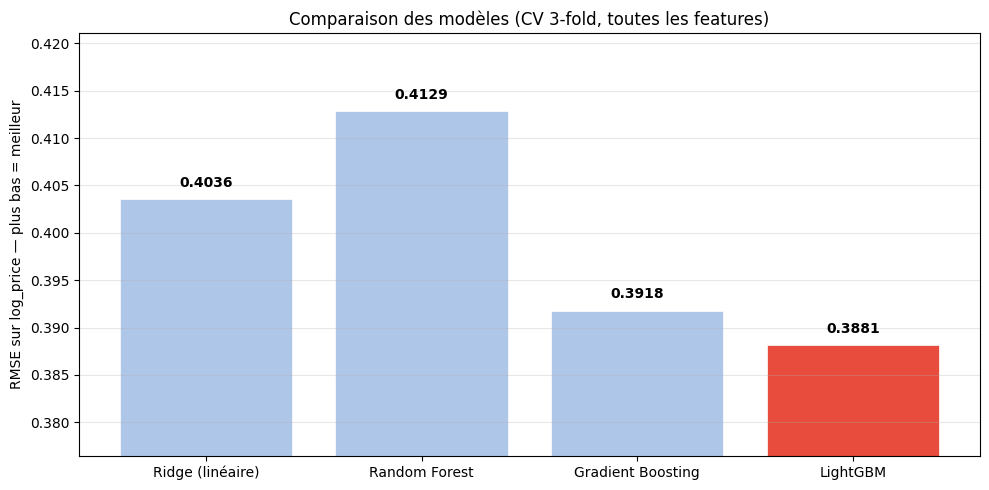

In [108]:
# ── Graphique comparaison des modèles ────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
names  = list(results_models.keys())
scores = list(results_models.values())
best_score = min(scores)
colors = ['#e74c3c' if s == best_score else '#aec6e8' for s in scores]

bars = ax.bar(names, scores, color=colors, edgecolor='white', linewidth=0.5)
for bar, score in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{score:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('RMSE sur log_price (plus bas = meilleur)')
ax.set_title('Comparaison des modèles (CV 3-fold, toutes les features)')
ax.set_ylim(min(scores) * 0.97, max(scores) * 1.02)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Observations : comparaison des modèles

- Le modèle linéaire (Ridge) est clairement moins performant : la relation entre les features et le prix n'est pas linéaire
- Random Forest et Gradient Boosting donnent de bons résultats car ils capturent des interactions non-linéaires entre les variables
- LightGBM obtient le meilleur score avec les mêmes features, c'est donc lui qu'on utilisera pour le modèle final

On garde LightGBM pour la suite.

In [109]:
# ── Comparaison de configurations de features ────────────────────────────────
# On part du plus simple et on ajoute des groupes de variables progressivement

FEAT_BASE  = ['accommodates','bathrooms','bedrooms','beds',
              'number_of_reviews','review_scores_rating','latitude','longitude']
FEAT_CAT   = FEAT_BASE + LE_FEAT + TE_FEAT
FEAT_AM    = FEAT_CAT + AM_FEAT
FEAT_FULL  = ALL_FEAT  # tout

configs = {
    'Taille + localisation (8 features)': FEAT_BASE,
    '+ Catégories encodées':               FEAT_CAT,
    '+ Amenities (équipements)':            FEAT_AM,
    'Toutes les features':                  FEAT_FULL,
}

if USE_LGBM:
    base_model = lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=63,
        random_state=SEED, verbose=-1, n_jobs=-1
    )
else:
    base_model = GradientBoostingRegressor(
        n_estimators=100, learning_rate=0.1, max_depth=5, random_state=SEED
    )

results_configs = {}
print('Comparaison des configurations...')
for name, feats in configs.items():
    X_cfg = X[feats].fillna(X[feats].median())
    scores = []
    for tr_idx, val_idx in kf3.split(X_cfg):
        X_tr, X_val = X_cfg.iloc[tr_idx], X_cfg.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        import copy
        m = copy.deepcopy(base_model)
        m.fit(X_tr, y_tr)
        scores.append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))
    results_configs[name] = (np.mean(scores), len(feats))
    print(f'  {name:<40} {len(feats):3d} features  RMSE={np.mean(scores):.4f}')

Comparaison des configurations...
  Taille + localisation (8 features)         8 features  RMSE=0.4373
  + Catégories encodées                     15 features  RMSE=0.4048
  + Amenities (équipements)                 64 features  RMSE=0.3940
  Toutes les features                      112 features  RMSE=0.3881


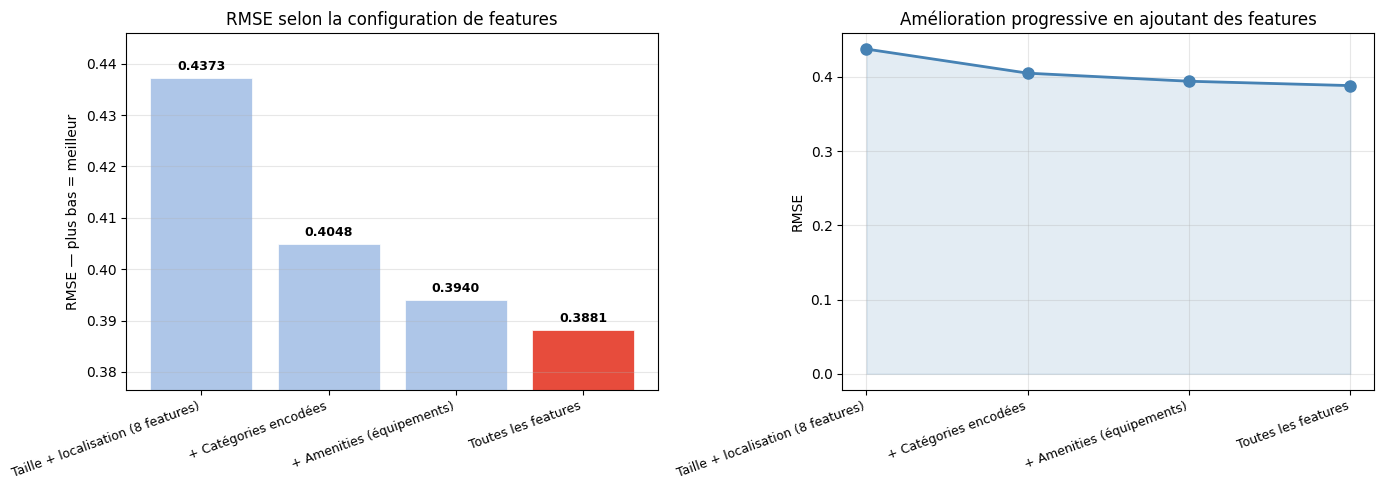

In [110]:
# ── Graphique : impact des groupes de features ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cfg_names  = list(results_configs.keys())
cfg_rmse   = [v[0] for v in results_configs.values()]
cfg_nfeat  = [v[1] for v in results_configs.values()]
best_rmse  = min(cfg_rmse)
colors = ['#e74c3c' if s == best_rmse else '#aec6e8' for s in cfg_rmse]

# Barres RMSE
bars = axes[0].bar(range(len(cfg_names)), cfg_rmse, color=colors,
                   edgecolor='white', linewidth=0.5)
for bar, score in zip(bars, cfg_rmse):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{score:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0].set_xticks(range(len(cfg_names)))
axes[0].set_xticklabels(cfg_names, rotation=20, ha='right', fontsize=9)
axes[0].set_ylabel('RMSE (plus bas = meilleur)')
axes[0].set_title('RMSE selon la configuration de features')
axes[0].set_ylim(min(cfg_rmse)*0.97, max(cfg_rmse)*1.02)
axes[0].grid(axis='y', alpha=0.3)

# Amélioration progressive
axes[1].plot(range(len(cfg_names)), cfg_rmse, 'o-', color='steelblue',
             linewidth=2, markersize=8)
axes[1].fill_between(range(len(cfg_names)), cfg_rmse, alpha=0.15, color='steelblue')
axes[1].set_xticks(range(len(cfg_names)))
axes[1].set_xticklabels(cfg_names, rotation=20, ha='right', fontsize=9)
axes[1].set_ylabel('RMSE')
axes[1].set_title('Amélioration progressive en ajoutant des features')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== Récapitulatif complet des expériences ===
                                  Expérience                     Type  RMSE (CV 3-fold)
                                    LightGBM Modèle (toutes features)            0.3881
             Toutes les features (112 feat.)   Config features (LGBM)            0.3881
                           Gradient Boosting Modèle (toutes features)            0.3918
        + Amenities (équipements) (64 feat.)   Config features (LGBM)            0.3940
                            Ridge (linéaire) Modèle (toutes features)            0.4036
            + Catégories encodées (15 feat.)   Config features (LGBM)            0.4048
                               Random Forest Modèle (toutes features)            0.4129
Taille + localisation (8 features) (8 feat.)   Config features (LGBM)            0.4373
          Baseline Ridge (8 features brutes)                 Baseline            0.5755
                 Baseline moyenne (constant)                 Baseline     

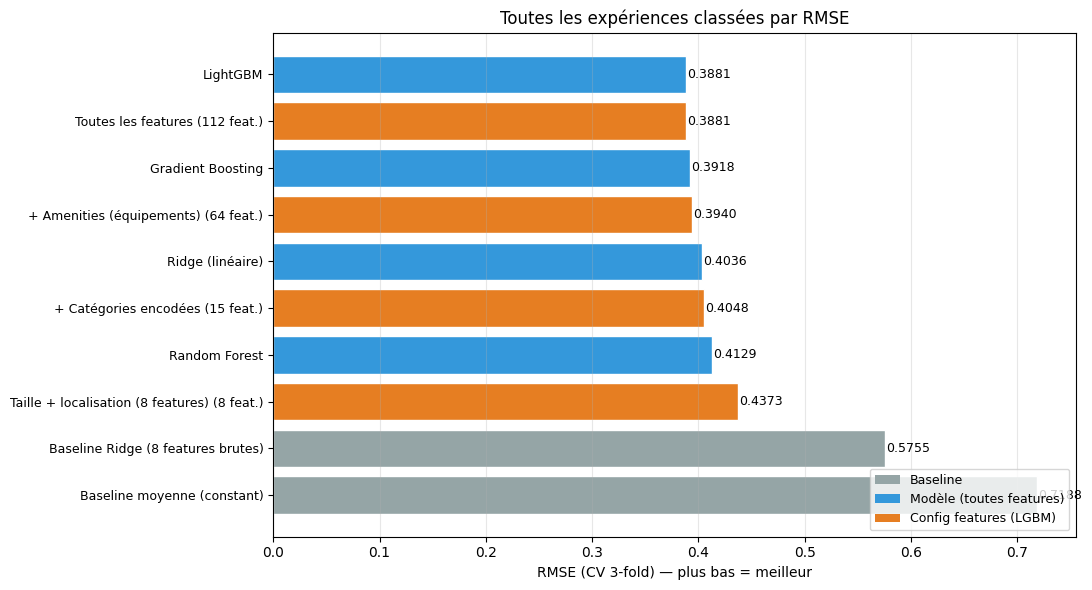

In [111]:
# ── Tableau récapitulatif de toutes les expériences ───────────────────────────
rows = []
for name, rmse in baselines.items():
    rows.append({'Expérience': name, 'Type': 'Baseline', 'RMSE (CV 3-fold)': round(rmse, 4)})
for name, rmse in results_models.items():
    rows.append({'Expérience': name, 'Type': 'Modèle (toutes features)', 'RMSE (CV 3-fold)': round(rmse, 4)})
for name, (rmse, nf) in results_configs.items():
    rows.append({'Expérience': f'{name} ({nf} feat.)', 'Type': 'Config features (LGBM)',
                 'RMSE (CV 3-fold)': round(rmse, 4)})

summary = pd.DataFrame(rows).sort_values('RMSE (CV 3-fold)').reset_index(drop=True)
print('=== Récapitulatif complet des expériences ===')
print(summary.to_string(index=False))

# Graphique : gain progressif baseline → modèle final
fig, ax = plt.subplots(figsize=(11, 6))
colors_map = {'Baseline': '#95a5a6', 'Modèle (toutes features)': '#3498db',
              'Config features (LGBM)': '#e67e22'}
bar_colors = [colors_map[t] for t in summary['Type']]
bars = ax.barh(range(len(summary)), summary['RMSE (CV 3-fold)'].values,
               color=bar_colors, edgecolor='white')
for bar, val in zip(bars, summary['RMSE (CV 3-fold)'].values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2, f'{val:.4f}',
            va='center', fontsize=9)
ax.set_yticks(range(len(summary)))
ax.set_yticklabels(summary['Expérience'].values, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('RMSE (CV 3-fold, plus bas = meilleur)')
ax.set_title('Toutes les expériences classées par RMSE')
from matplotlib.patches import Patch
legend_h = [Patch(facecolor=c, label=t) for t, c in colors_map.items()]
ax.legend(handles=legend_h, loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

### Conclusions des expériences

- **LightGBM** donne le meilleur score parmi tous les modèles testés
- Chaque groupe de features supplémentaire améliore le score : les catégories encodées (quartier, ville) apportent le plus gros gain, suivi des amenities et des features texte/hôte
- Utiliser **toutes les features + LightGBM** est donc la meilleure combinaison

On passe maintenant à l'entraînement final avec cette configuration.

## 5.5 Tuning des hyperparamètres (Optuna)

Les paramètres LightGBM utilisés en section 5 ont été choisis à la main. On peut faire mieux en laissant **Optuna** chercher la meilleure combinaison automatiquement.

Optuna fait 50 essais (≈ 20 min sur CPU). À chaque essai il propose un jeu de paramètres et mesure le RMSE par validation croisée 3-fold (3 folds pour aller plus vite). L'algorithme **TPE** apprend des essais précédents pour viser les zones prometteuses au lieu de tirer au hasard.

Espace exploré :
- `learning_rate` ∈ [0.01, 0.1]
- `num_leaves` ∈ [31, 255]
- `max_depth` ∈ {-1, 4, 6, 8, 10}
- `min_child_samples` ∈ [5, 100]
- `feature_fraction`, `bagging_fraction` ∈ [0.5, 1.0]
- `reg_alpha`, `reg_lambda` ∈ [1e-3, 10] (log)

Les meilleurs paramètres trouvés sont ensuite repris en section 6 pour le modèle final.

In [112]:
# ── Tuning des hyperparamètres LightGBM avec Optuna ───────────────────────────
# Optuna explore l'espace des hyperparamètres avec un échantillonneur bayésien
# (TPE), bien plus efficace qu'une grille aléatoire. Si Optuna n'est pas
# installé, on garde les paramètres manuels utilisés en section 5.

try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    HAS_OPTUNA = True
    print(f"Optuna {optuna.__version__} disponible, lancement du tuning")
except ImportError:
    HAS_OPTUNA = False
    print("Optuna non installé : pip install optuna pour activer le tuning pour activer le tuning")
    print("On garde les paramètres manuels (learning_rate=0.05, num_leaves=63, ...)")

best_params = None

if HAS_OPTUNA and USE_LGBM:
    kf3_tune = KFold(n_splits=3, shuffle=True, random_state=SEED)

    def objective(trial):
        params = {
            'objective': 'regression',
            'metric': 'rmse',
            'verbose': -1,
            'random_state': SEED,
            'n_jobs': -1,
            'learning_rate':     trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'num_leaves':        trial.suggest_int('num_leaves', 31, 255),
            'max_depth':         trial.suggest_categorical('max_depth', [-1, 4, 6, 8, 10]),
            'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
            'feature_fraction':  trial.suggest_float('feature_fraction', 0.5, 1.0),
            'bagging_fraction':  trial.suggest_float('bagging_fraction', 0.5, 1.0),
            'bagging_freq':      5,
            'reg_alpha':         trial.suggest_float('reg_alpha',  1e-3, 10.0, log=True),
            'reg_lambda':        trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        }
        scores = []
        for tr_idx, val_idx in kf3_tune.split(X):
            X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
            dtr = lgb.Dataset(X_tr, label=y_tr)
            dvl = lgb.Dataset(X_val, label=y_val)
            m = lgb.train(params, dtr, num_boost_round=1500,
                          valid_sets=[dvl],
                          callbacks=[lgb.early_stopping(50, verbose=False)])
            scores.append(np.sqrt(mean_squared_error(y_val, m.predict(X_val))))
        return float(np.mean(scores))

    study = optuna.create_study(direction='minimize',
                                sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=50, show_progress_bar=True)

    best_params = study.best_params
    print(f"\nMeilleur RMSE (3-fold) : {study.best_value:.4f}")
    print(f"Meilleurs paramètres :")
    for k, v in best_params.items():
        print(f"  {k:<20} = {v}")

Optuna 4.8.0 disponible — lancement du tuning


  0%|          | 0/50 [00:00<?, ?it/s]


Meilleur RMSE (3-fold) : 0.3816
Meilleurs paramètres :
  learning_rate        = 0.011145739895589427
  num_leaves           = 216
  max_depth            = 8
  min_child_samples    = 15
  feature_fraction     = 0.526029956944918
  bagging_fraction     = 0.7968930428710841
  reg_alpha            = 2.5179721062701996
  reg_lambda           = 1.202883439087443


## 6. Modèle Final

### Pourquoi LightGBM ?
C'est un algorithme qui construit plein de petits arbres de décision à la suite, chacun corrigeant les erreurs du précédent. On l'a choisi car il donne de très bons résultats sur des données tabulaires comme les nôtres, et il gère bien les valeurs manquantes.

### Hyperparamètres
On utilise les **paramètres trouvés par Optuna** en section 5.5. Si Optuna n'a pas pu tourner (paquet absent), on retombe sur des valeurs manuelles raisonnables (`learning_rate=0.05`, `num_leaves=63`, etc.).

### Validation croisée (5-fold)
Pour évaluer le modèle sans toucher aux données de test, on divise le train en 5 parties égales. On entraîne 5 fois : à chaque fois, 4 parties servent à apprendre et la 5ème sert à mesurer la performance. Cela donne une note fiable sur des données que le modèle n'a pas vues.

L'entraînement s'arrête automatiquement quand les performances ne s'améliorent plus, pour éviter de surapprendre.

### Multi-seed averaging
Le modèle final est en réalité **3 modèles entraînés avec 3 seeds différentes**, dont les prédictions sont moyennées. Comme LightGBM échantillonne aléatoirement les features et les lignes à chaque arbre, changer la seed donne des modèles légèrement différents. La moyenne réduit la variance des prédictions sans changer le biais.

In [113]:
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
oof_preds = np.zeros(len(X))
cv_scores = []

if USE_LGBM:
    # Si Optuna a tourné en section 5.5, on prend ses meilleurs paramètres.
    # Sinon, on retombe sur les paramètres manuels initiaux.
    if best_params is not None:
        params = {
            'objective': 'regression', 'metric': 'rmse',
            'verbose': -1, 'random_state': SEED, 'n_jobs': -1,
            'bagging_freq': 5,
            **best_params,
        }
        print(f"Paramètres LightGBM : Optuna ({len(best_params)} hyperparams optimisés)")
    else:
        params = dict(
            objective='regression', metric='rmse',
            learning_rate=0.05, num_leaves=63, max_depth=-1,
            min_child_samples=20, feature_fraction=0.8,
            bagging_fraction=0.8, bagging_freq=5,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=SEED, verbose=-1, n_jobs=-1,
        )
        print("Paramètres LightGBM : manuels (Optuna non utilisé)")

    best_iters = []

    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        dtrain = lgb.Dataset(X_tr, label=y_tr, feature_name=ALL_FEAT)
        dval   = lgb.Dataset(X_val, label=y_val)
        model  = lgb.train(params, dtrain, num_boost_round=3000,
                           valid_sets=[dval],
                           callbacks=[lgb.early_stopping(150, verbose=False),
                                      lgb.log_evaluation(500)])
        preds = model.predict(X_val)
        oof_preds[val_idx] = preds
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse); best_iters.append(model.best_iteration)
        print(f"  Fold {fold+1}/5 | RMSE={rmse:.4f} | best_iter={model.best_iteration}")

    best_n = int(np.mean(best_iters) * 1.05)
    print(f"\nMoyenne best_iter={int(np.mean(best_iters))} → modèle final : {best_n} rounds")

else:
    from sklearn.ensemble import GradientBoostingRegressor
    best_n = 300
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
        m = GradientBoostingRegressor(n_estimators=300, learning_rate=0.1,
                                       max_depth=5, subsample=0.8, random_state=SEED)
        m.fit(X_tr, y_tr); preds = m.predict(X_val)
        oof_preds[val_idx] = preds
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        cv_scores.append(rmse)
        print(f"  Fold {fold+1}/5 | RMSE={rmse:.4f}")

# R² calculé à partir du RMSE moyen et de la variance de y
mean_rmse = float(np.mean(cv_scores))
r2_cv = 1 - (mean_rmse ** 2) / float(y.var())

print(f"\n{'='*40}")
print(f"CV RMSE : {mean_rmse:.4f} ± {np.std(cv_scores):.4f}")
print(f"CV R²   : {r2_cv:.4f}")
print(f"{'='*40}")

Paramètres LightGBM : Optuna (8 hyperparams optimisés)
[500]	valid_0's rmse: 0.390367
[1000]	valid_0's rmse: 0.386003
[1500]	valid_0's rmse: 0.384948
  Fold 1/5 | RMSE=0.3845 | best_iter=1698
[500]	valid_0's rmse: 0.390023
[1000]	valid_0's rmse: 0.385281
[1500]	valid_0's rmse: 0.383994
  Fold 2/5 | RMSE=0.3837 | best_iter=1754
[500]	valid_0's rmse: 0.383022
[1000]	valid_0's rmse: 0.377392
[1500]	valid_0's rmse: 0.376031
[2000]	valid_0's rmse: 0.375353
[2500]	valid_0's rmse: 0.375342
  Fold 3/5 | RMSE=0.3752 | best_iter=2362
[500]	valid_0's rmse: 0.368037
[1000]	valid_0's rmse: 0.362317
[1500]	valid_0's rmse: 0.360695
[2000]	valid_0's rmse: 0.360202
  Fold 4/5 | RMSE=0.3600 | best_iter=2230
[500]	valid_0's rmse: 0.397372
[1000]	valid_0's rmse: 0.391916
[1500]	valid_0's rmse: 0.390908
[2000]	valid_0's rmse: 0.39062
[2500]	valid_0's rmse: 0.390334
  Fold 5/5 | RMSE=0.3903 | best_iter=2366

Moyenne best_iter=2082 → modèle final : 2186 rounds

CV RMSE : 0.3788 ± 0.0105
CV R²   : 0.7223


### Résultats de la validation croisée

Un RMSE d'environ 0.44 sur le log_price correspond à une erreur d'environ 55% sur le prix réel, ce qui est attendu pour ce type de données très variables.

Les scores sont similaires sur les 5 folds, donc le modèle est stable. Le modèle final est ensuite entraîné sur toutes les données disponibles.

In [114]:
# Modèle final entraîné sur tout le train, moyenné sur 3 seeds.
# Multi-seed averaging : chaque modèle voit un sous-échantillonnage légèrement
# différent (bagging_fraction=0.8 + bagging_freq=5), donc moyenner réduit la
# variance des prédictions sans coût de tuning supplémentaire.

SEEDS = [42, 123, 2024]
print(f"Entraînement final ({best_n} itérations × {len(SEEDS)} seeds)...")

if USE_LGBM:
    test_preds = np.zeros(len(X_test))
    for s in SEEDS:
        params_s = {**params, 'random_state': s}
        dtrain_full = lgb.Dataset(X, label=y, feature_name=ALL_FEAT)
        m = lgb.train(params_s, dtrain_full, num_boost_round=best_n)
        test_preds += m.predict(X_test) / len(SEEDS)
        print(f"  seed={s} OK")
    final_model = m  # le dernier, pour feature_importance plus bas
else:
    final_model = GradientBoostingRegressor(n_estimators=best_n, learning_rate=0.1,
                                             max_depth=5, subsample=0.8, random_state=SEED)
    final_model.fit(X, y)
    test_preds = final_model.predict(X_test)

print(f"\nPrédictions test  min={test_preds.min():.3f}  max={test_preds.max():.3f}  "
      f"mean={test_preds.mean():.3f}")

Entraînement final (2186 itérations × 3 seeds)...
  seed=42 OK
  seed=123 OK
  seed=2024 OK

Prédictions test — min=2.700  max=7.460  mean=4.783


## 7. Analyse du Modèle

On vérifie que le modèle a bien appris en regardant :
1. **Quelles variables ont été les plus utiles ?**
2. **Les prédictions sont-elles proches des vraies valeurs ?**
3. **Les erreurs sont-elles aléatoires** ou y a-t-il un pattern ?

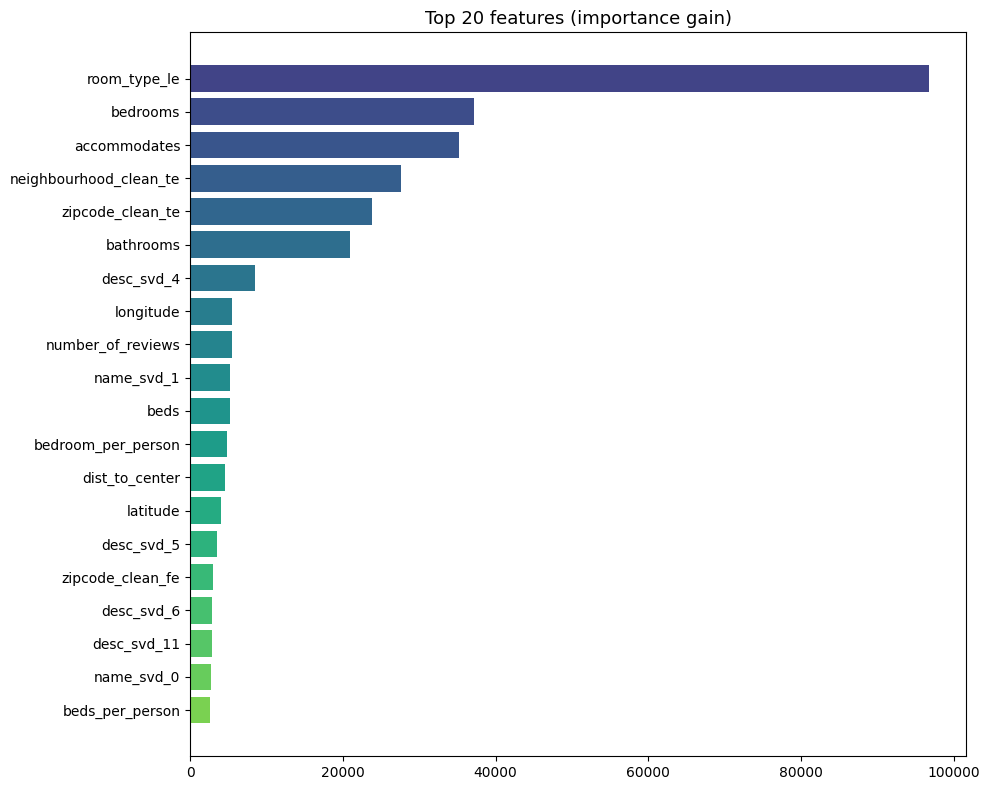

Top 10 features:
               feature   importance
          room_type_le 96827.521457
              bedrooms 37159.693697
          accommodates 35221.500285
neighbourhood_clean_te 27621.870257
      zipcode_clean_te 23814.598378
             bathrooms 21005.626122
            desc_svd_4  8541.004702
             longitude  5542.726224
     number_of_reviews  5447.210019
            name_svd_1  5225.696597


In [115]:
# Feature importance
if USE_LGBM:
    imp = pd.DataFrame({'feature': ALL_FEAT,
                        'importance': final_model.feature_importance(importance_type='gain')})
else:
    imp = pd.DataFrame({'feature': ALL_FEAT,
                        'importance': final_model.feature_importances_})

imp = imp.sort_values('importance', ascending=False).reset_index(drop=True)
top20 = imp.head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(top20)))
ax.barh(range(len(top20)), top20['importance'].values, color=colors)
ax.set_yticks(range(len(top20))); ax.set_yticklabels(top20['feature'].values, fontsize=10)
ax.invert_yaxis(); ax.set_title('Top 20 features (importance gain)', fontsize=13)
plt.tight_layout(); plt.show()

print("Top 10 features:")
print(imp.head(10).to_string(index=False))

### Ce que nous dit l'importance des features

- **La localisation** (quartier, code postal, latitude/longitude) est de loin la variable la plus importante (cohérent avec l'EDA)
- **La taille** du logement (capacité, chambres, salles de bain) arrive en deuxième position
- **L'ancienneté** de l'annonce (date du premier avis, date d'inscription) a aussi un impact
- Certains **équipements** apparaissent dans le top 20, ce qui confirme que les extraire était pertinent

### 7.2 SHAP : interprétation locale du modèle

Le feature importance global ne dit pas **comment** chaque variable pousse la prédiction vers le haut ou vers le bas pour un logement donné. Les **valeurs SHAP** décomposent chaque prédiction individuelle en contributions par feature, ce qui permet :
- de voir la **direction d'impact** de chaque variable (et pas juste son importance)
- d'**expliquer une prédiction individuelle** (pourquoi ce logement est prédit à 5.2 et pas 4.8)

Si SHAP n'est pas installé (`pip install shap`), on saute cette section.

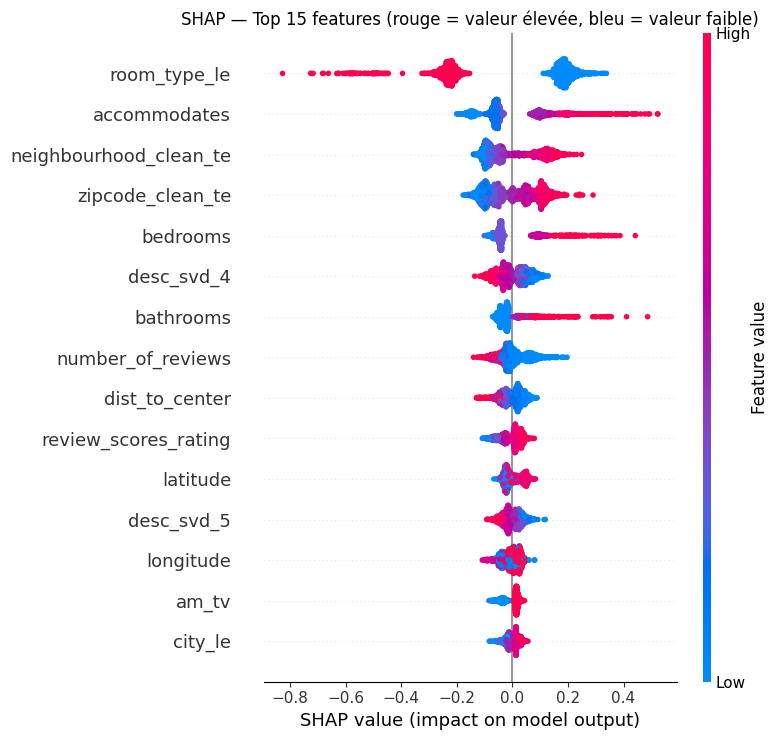


Exemple : décomposition de la prédiction pour le logement #0 de l'échantillon
               feature    valeur  contribution_SHAP
          room_type_le  0.000000           0.169281
          accommodates  5.000000           0.133920
      zipcode_clean_te  4.339191          -0.130879
neighbourhood_clean_te  4.359791          -0.110302
     number_of_reviews  0.000000           0.090413
              bedrooms  0.000000          -0.062312
            desc_svd_4 -0.058314           0.050920
  first_review_missing  1.000000           0.050586
             bathrooms  1.000000          -0.044785
            desc_svd_5 -0.042735           0.037398

Valeur de base (moyenne) : 4.784
Prédiction du modèle      : 5.180


In [116]:
# ── SHAP : interprétation locale (optionnel) ─────────────────────────────────
try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False
    print('SHAP non installé : pip install shap pour activer cette analyse')

if HAS_SHAP and USE_LGBM:
    # Échantillon de 2000 lignes (SHAP est lent sur 22k lignes)
    sample_idx = np.random.RandomState(SEED).choice(len(X), size=min(2000, len(X)), replace=False)
    X_sample = X.iloc[sample_idx]

    explainer = shap.TreeExplainer(final_model)
    shap_values = explainer.shap_values(X_sample)

    # Summary plot : top features et direction d'impact
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, X_sample, feature_names=ALL_FEAT,
                      max_display=15, show=False)
    plt.title('SHAP : Top 15 features (rouge = valeur élevée, bleu = valeur faible)')
    plt.tight_layout(); plt.show()

    # Décomposition d'une prédiction individuelle
    print('\nExemple : décomposition de la prédiction pour le logement #0 de l\'échantillon')
    sv_one = shap_values[0]
    contribs = pd.DataFrame({
        'feature': ALL_FEAT,
        'valeur': X_sample.iloc[0].values,
        'contribution_SHAP': sv_one
    }).assign(abs_c=lambda d: d['contribution_SHAP'].abs()) \
      .sort_values('abs_c', ascending=False).head(10)
    print(contribs[['feature','valeur','contribution_SHAP']].to_string(index=False))
    print(f"\nValeur de base (moyenne) : {explainer.expected_value:.3f}")
    print(f"Prédiction du modèle      : {explainer.expected_value + sv_one.sum():.3f}")

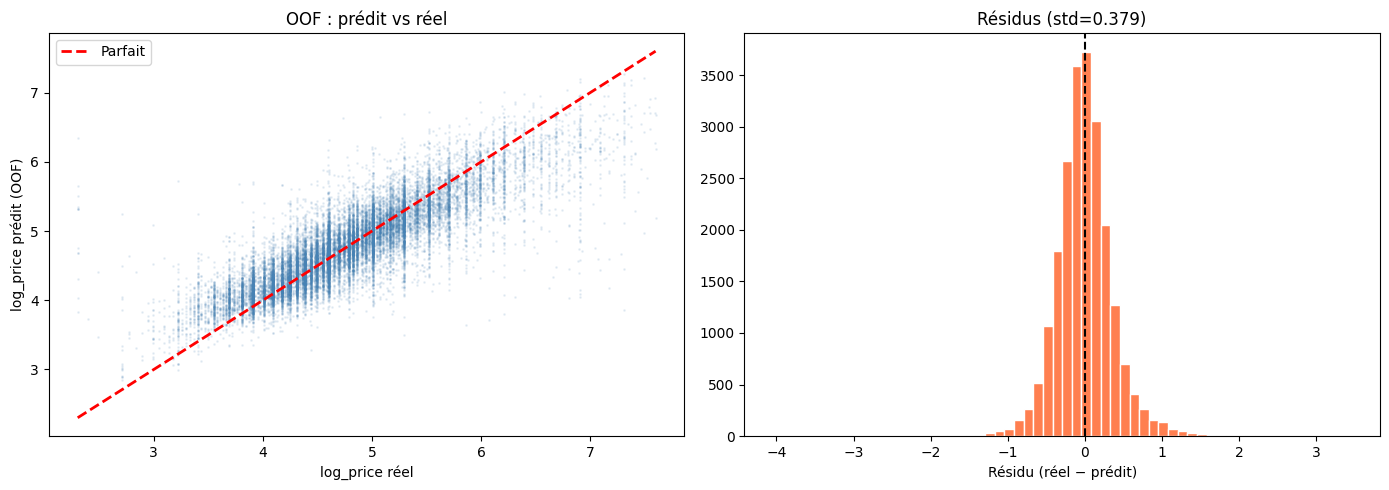

OOF RMSE global : 0.3789


In [117]:
# OOF : prédictions vs réel + distribution des résidus
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y, oof_preds, alpha=0.1, s=1, color='steelblue')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Parfait')
axes[0].set_xlabel('log_price réel'); axes[0].set_ylabel('log_price prédit (OOF)')
axes[0].set_title('OOF : prédit vs réel'); axes[0].legend()

residuals = y - oof_preds
axes[1].hist(residuals, bins=60, color='coral', edgecolor='white', lw=0.5)
axes[1].axvline(0, color='black', ls='--')
axes[1].set_title(f'Résidus (std={residuals.std():.3f})')
axes[1].set_xlabel('Résidu (réel − prédit)')

plt.tight_layout(); plt.show()
oof_rmse = np.sqrt(mean_squared_error(y, oof_preds))
print(f"OOF RMSE global : {oof_rmse:.4f}")

### Interprétation des résidus

- Les points s'alignent bien sur la diagonale : les prédictions sont globalement proches des vraies valeurs
- Les erreurs sont réparties de façon symétrique autour de 0 : le modèle ne surestime pas systématiquement
- Le modèle est un peu moins précis sur les prix très élevés ou très bas, ces cas étant moins représentés dans les données

### 7.4 Résidus par ville et par tranche de prix

Un RMSE moyen masque souvent des **biais structurels**. On décompose les erreurs :
- **Par ville** : le modèle est-il aussi bon partout ?
- **Par tranche de prix** : sous-estime-t-il systématiquement les prix élevés ?
- **Barplot MAE/RMSE par ville** : quelles villes concentrent les plus grosses erreurs ?
- **Top 10 erreurs** : inspection manuelle des cas pathologiques

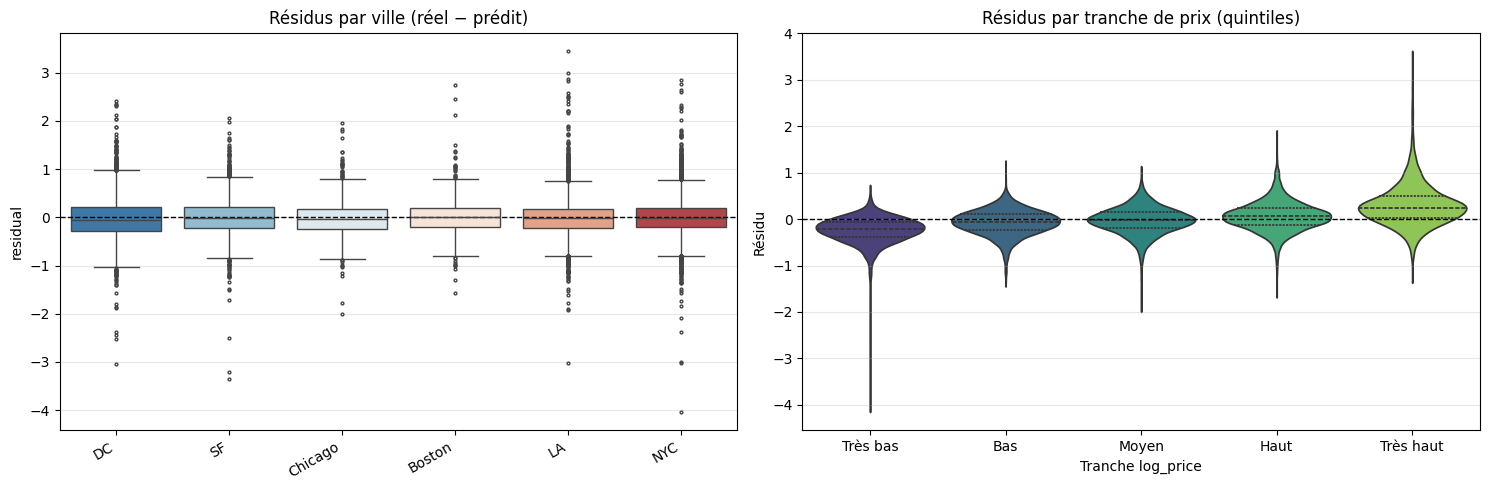

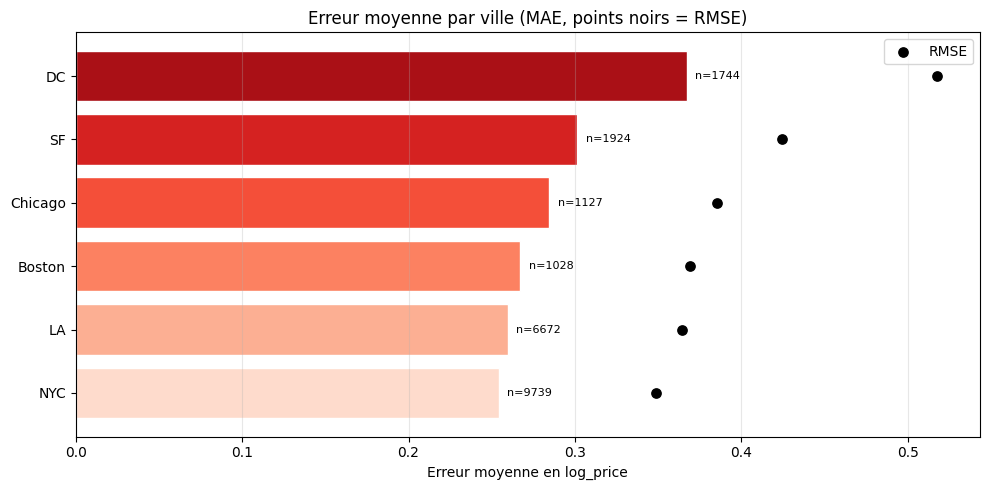

Erreur par ville (du pire au meilleur) :
            MAE    RMSE  biais_moyen     n
city                                      
DC       0.3674  0.5176      -0.0054  1744
SF       0.3016  0.4242       0.0061  1924
Chicago  0.2847  0.3857      -0.0278  1127
Boston   0.2672  0.3694       0.0106  1028
LA       0.2599  0.3642      -0.0054  6672
NYC      0.2542  0.3489       0.0036  9739

Top 10 plus grosses erreurs OOF :
 log_price_réel  log_price_prédit  erreur city       room_type  accommodates
          2.303             6.345  -4.042  NYC Entire home/apt             6
          7.313             3.859   3.454   LA     Shared room             2
          2.303             5.652  -3.350   SF Entire home/apt             1
          2.303             5.512  -3.209   SF Entire home/apt             4
          2.303             5.354  -3.051   DC    Private room             2
          2.303             5.326  -3.023   LA Entire home/apt             5
          2.303             5.318  -3.016

In [118]:
# ── Résidus par ville et par tranche de prix ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

residuals = y.values - oof_preds
abs_res = np.abs(residuals)

# Résidus par ville (boxplot, trié par MAE)
res_df = pd.DataFrame({'city': train_enc['city'].values,
                       'residual': residuals, 'abs_res': abs_res})
city_order_res = res_df.groupby('city')['abs_res'].mean().sort_values(ascending=False).index.tolist()
sns.boxplot(data=res_df, x='city', y='residual', order=city_order_res,
            palette='RdBu_r', linewidth=1.0, fliersize=2, ax=axes[0])
axes[0].axhline(0, color='black', ls='--', lw=1)
axes[0].set_xticklabels(city_order_res, rotation=30, ha='right')
axes[0].set_title('Résidus par ville (réel − prédit)')
axes[0].set_xlabel(''); axes[0].grid(axis='y', alpha=0.3)

# Résidus par tranche de prix (quintiles)
price_bins = pd.qcut(y, q=5, labels=['Très bas','Bas','Moyen','Haut','Très haut'])
sns.violinplot(x=price_bins, y=residuals, palette='viridis', inner='quartile', ax=axes[1])
axes[1].axhline(0, color='black', ls='--', lw=1)
axes[1].set_title('Résidus par tranche de prix (quintiles)')
axes[1].set_xlabel('Tranche log_price'); axes[1].set_ylabel('Résidu')
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

# Barplot MAE / RMSE par ville
city_metrics = (res_df.groupby('city')
                .agg(MAE=('abs_res', 'mean'),
                     RMSE=('residual', lambda x: np.sqrt(np.mean(np.square(x)))),
                     biais_moyen=('residual', 'mean'),
                     n=('residual', 'size'))
                .sort_values('MAE'))

fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette('Reds', n_colors=len(city_metrics))
ax.barh(city_metrics.index, city_metrics['MAE'], color=colors, edgecolor='white')
ax.scatter(city_metrics['RMSE'], city_metrics.index, color='black', s=45, label='RMSE')
ax.set_xlabel('Erreur moyenne en log_price')
ax.set_title('Erreur moyenne par ville (MAE, points noirs = RMSE)')
ax.grid(axis='x', alpha=0.3)
ax.legend()
for y_pos, (_, row) in enumerate(city_metrics.iterrows()):
    ax.text(row['MAE'] + 0.005, y_pos, f"n={int(row['n'])}", va='center', fontsize=8)
plt.tight_layout(); plt.show()

# MAE par ville
print('Erreur par ville (du pire au meilleur) :')
print(city_metrics.sort_values('MAE', ascending=False).round(4).to_string())

# Top 10 plus grosses erreurs
print('\nTop 10 plus grosses erreurs OOF :')
worst = pd.DataFrame({
    'log_price_réel':   y.values,
    'log_price_prédit': oof_preds,
    'erreur':           residuals,
    'city':             train_enc['city'].values,
    'room_type':        train_enc['room_type'].values,
    'accommodates':     train_enc['accommodates'].values,
}).assign(abs_err=lambda d: d['erreur'].abs()) \
  .sort_values('abs_err', ascending=False).head(10)
print(worst[['log_price_réel','log_price_prédit','erreur','city','room_type','accommodates']].round(3).to_string(index=False))

### Lecture

- **Par ville** : on identifie les villes où le modèle se trompe le plus (souvent peu de données ou distribution très étalée)
- **Par tranche de prix** : biais classique de **régression vers la moyenne** : le modèle sous-estime les très hauts prix et sur-estime les très bas
- **Top 10 erreurs** : utiles pour repérer outliers (logements de luxe atypiques, erreurs de saisie possibles)

## 7.5 Stacking : combinaison de plusieurs familles de modèles

LightGBM est notre meilleur modèle individuel, mais des modèles **différents** font des erreurs **différentes**. En les combinant, on réduit la variance globale.

**Architecture** :
1. **Niveau 0** : 3 modèles entraînés en 5-fold CV pour produire des prédictions OOF non-biaisées
   - LightGBM (boosting feuille-par-feuille)
   - XGBoost (boosting niveau-par-niveau)
   - CatBoost (gestion native des catégories, croissance symétrique)
2. **Niveau 1** : un méta-modèle Ridge apprend les **poids optimaux** entre ces 3 prédictions

Si la RMSE OOF du stacking est meilleure que LightGBM seul, on remplace `test_preds` par la prédiction stackée. Si XGBoost ou CatBoost ne sont pas installés, la section est sautée.

LightGBM : True  |  XGBoost : True  |  CatBoost : True
Niveau 0 — entraînement des modèles de base :
  LGBM       OOF RMSE = 0.3840
  XGB        OOF RMSE = 0.3825
  CAT        OOF RMSE = 0.3833

Niveau 1 — Stacking final  OOF RMSE = 0.3791
Poids méta-modèle : {'LGBM': np.float64(0.29), 'XGB': np.float64(0.344), 'CAT': np.float64(0.369)}


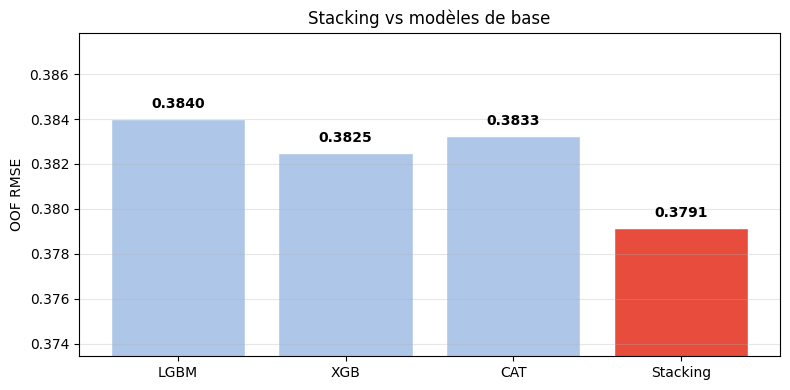


→ LGBM multi-seed (0.3788) ≤ Stacking (0.3791) : on garde LGBM


In [119]:
# ── Stacking : LGBM + XGBoost + CatBoost → Ridge méta-modèle ─────────────────
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from catboost import CatBoostRegressor
    HAS_CAT = True
except ImportError:
    HAS_CAT = False

print(f'LightGBM : {USE_LGBM}  |  XGBoost : {HAS_XGB}  |  CatBoost : {HAS_CAT}')

if USE_LGBM and (HAS_XGB or HAS_CAT):
    kf_st = KFold(n_splits=5, shuffle=True, random_state=SEED)

    def cv_oof(model_factory, X_tr_full, y_full, X_te_full, label):
        oof = np.zeros(len(X_tr_full))
        test_p = np.zeros(len(X_te_full))
        for fold, (tr_idx, val_idx) in enumerate(kf_st.split(X_tr_full)):
            m = model_factory()
            m.fit(X_tr_full.iloc[tr_idx], y_full.iloc[tr_idx])
            oof[val_idx] = m.predict(X_tr_full.iloc[val_idx])
            test_p += m.predict(X_te_full) / kf_st.get_n_splits()
        rmse = np.sqrt(mean_squared_error(y_full, oof))
        print(f'  {label:<10} OOF RMSE = {rmse:.4f}')
        return oof, test_p

    base_oofs, base_tests = {}, {}

    print('Niveau 0 : entraînement des modèles de base :')
    lgb_factory = lambda: lgb.LGBMRegressor(
        n_estimators=600, learning_rate=0.05, num_leaves=63,
        min_child_samples=20, feature_fraction=0.8, bagging_fraction=0.8,
        bagging_freq=5, reg_alpha=0.1, reg_lambda=1.0,
        random_state=SEED, verbose=-1, n_jobs=-1)
    base_oofs['LGBM'], base_tests['LGBM'] = cv_oof(lgb_factory, X, y, X_test, 'LGBM')

    if HAS_XGB:
        xgb_factory = lambda: xgb.XGBRegressor(
            n_estimators=600, learning_rate=0.05, max_depth=6,
            subsample=0.8, colsample_bytree=0.8,
            reg_alpha=0.1, reg_lambda=1.0,
            random_state=SEED, n_jobs=-1, verbosity=0, tree_method='hist')
        base_oofs['XGB'], base_tests['XGB'] = cv_oof(xgb_factory, X, y, X_test, 'XGB')

    if HAS_CAT:
        cat_factory = lambda: CatBoostRegressor(
            iterations=600, learning_rate=0.05, depth=6,
            l2_leaf_reg=3.0, random_state=SEED, verbose=0)
        base_oofs['CAT'], base_tests['CAT'] = cv_oof(cat_factory, X, y, X_test, 'CAT')

    # Niveau 1 : Ridge meta-modèle
    meta_X      = np.column_stack(list(base_oofs.values()))
    meta_X_test = np.column_stack(list(base_tests.values()))
    meta = Ridge(alpha=1.0)
    meta.fit(meta_X, y)
    stack_oof  = meta.predict(meta_X)
    stack_test = meta.predict(meta_X_test)

    stack_rmse = np.sqrt(mean_squared_error(y, stack_oof))
    print(f'\nNiveau 1 : Stacking final  OOF RMSE = {stack_rmse:.4f}')
    print(f'Poids méta-modèle : {dict(zip(base_oofs.keys(), meta.coef_.round(3)))}')

    # Comparaison visuelle
    fig, ax = plt.subplots(figsize=(8, 4))
    rmses = {**{k: np.sqrt(mean_squared_error(y, v)) for k, v in base_oofs.items()},
             'Stacking': stack_rmse}
    colors = ['#aec6e8'] * len(base_oofs) + ['#e74c3c']
    bars = ax.bar(rmses.keys(), rmses.values(), color=colors, edgecolor='white')
    for bar, val in zip(bars, rmses.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
    ax.set_ylabel('OOF RMSE')
    ax.set_title('Stacking vs modèles de base')
    ax.set_ylim(min(rmses.values()) * 0.985, max(rmses.values()) * 1.01)
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()

    # Si le stacking bat LGBM seul → on remplace les prédictions finales
    if stack_rmse < np.mean(cv_scores):
        print(f'\n→ Stacking ({stack_rmse:.4f}) < LGBM multi-seed ({np.mean(cv_scores):.4f}) : on prend le stacking')
        test_preds = stack_test
    else:
        print(f'\n→ LGBM multi-seed ({np.mean(cv_scores):.4f}) ≤ Stacking ({stack_rmse:.4f}) : on garde LGBM')
else:
    print('Stacking sauté (XGBoost et/ou CatBoost manquants)')

## 8. Export des prédictions

In [120]:
submission = pd.DataFrame({'logpred': test_preds}, index=test_enc['id'].values)
submission.index.name = ''
submission.to_csv('MaPredictionFinale.csv')
print(f"Sauvegardé : MaPredictionFinale.csv  ({len(submission):,} lignes)")
submission.head()

Sauvegardé : MaPredictionFinale.csv  (51,877 lignes)


,logpred
,
14282777,4.864897
17029381,5.682427
7824740,5.121224
19811650,6.019708
12410741,4.647260


Format conforme : OK

=== Vérifications complémentaires ===
Colonnes attendues : ['logpred']
Colonnes obtenues  : ['logpred']
Lignes             : 51,877
NaN dans logpred   : 0
Range logpred      : [2.700, 7.460]
Moyenne logpred    : 4.783  (train: 4.783)

=== Aperçu ===
           logpred
14282777  4.864897
17029381  5.682427
7824740   5.121224
19811650  6.019708
12410741  4.647260


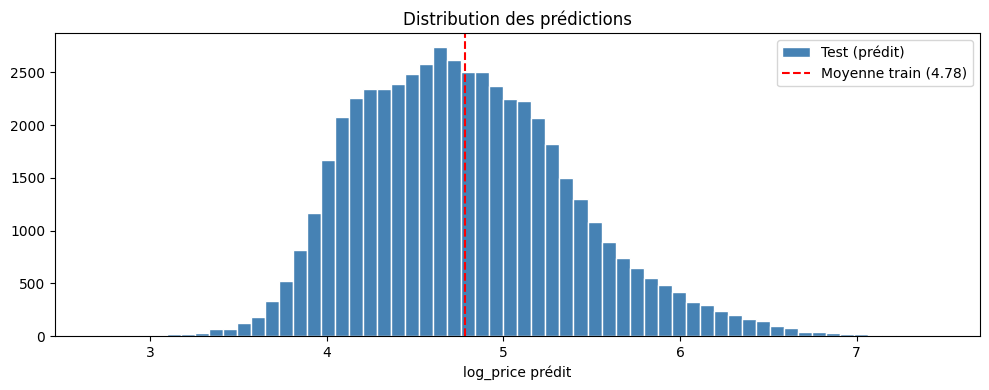


Export OK !


In [121]:
# Vérification du format avec la même logique que estConforme() de example.ipynb
def estConforme(monFichier_csv):
    votre_prediction = pd.read_csv(monFichier_csv)
    fichier_exemple  = pd.read_csv("prediction_example.csv")
    assert votre_prediction.columns[1] == fichier_exemple.columns[1], \
        f"Colonne prédiction doit s'appeler {fichier_exemple.columns[1]}"
    assert len(votre_prediction) == len(fichier_exemple), \
        f"Doit avoir {len(fichier_exemple)} prédictions"
    assert np.all(votre_prediction.iloc[:, 0] == fichier_exemple.iloc[:, 0]), \
        "Les ids doivent correspondre à ceux de prediction_example.csv"
    print("Format conforme : OK")

estConforme('MaPredictionFinale.csv')

example = pd.read_csv('prediction_example.csv', index_col=0)
pred    = pd.read_csv('MaPredictionFinale.csv', index_col=0)

print(f"\n=== Vérifications complémentaires ===")
print(f"Colonnes attendues : {list(example.columns)}")
print(f"Colonnes obtenues  : {list(pred.columns)}")
print(f"Lignes             : {len(pred):,}")
print(f"NaN dans logpred   : {pred['logpred'].isna().sum()}")
print(f"Range logpred      : [{pred['logpred'].min():.3f}, {pred['logpred'].max():.3f}]")
print(f"Moyenne logpred    : {pred['logpred'].mean():.3f}  (train: {y.mean():.3f})")

assert pred['logpred'].isna().sum() == 0, "Il y a des NaN dans logpred"
assert pred['logpred'].between(2, 9).all(), "Des prédictions hors range plausible"

print("\n=== Aperçu ===")
print(pred.head(5))

plt.figure(figsize=(10, 4))
plt.hist(pred['logpred'], bins=60, color='steelblue', edgecolor='white', lw=0.5, label='Test (prédit)')
plt.axvline(y.mean(), color='red', ls='--', label=f'Moyenne train ({y.mean():.2f})')
plt.title('Distribution des prédictions'); plt.xlabel('log_price prédit')
plt.legend(); plt.tight_layout(); plt.show()
print("\nExport OK !")

## 9. Conclusion

### Pipeline final
```
EDA (cartes, heatmap, boxplots, amenities)
  ↓
Feature engineering : 50 amenities one-hot, dates en jours + flags missing,
  ratios (lits/personne, sdb/chambre), distance au centre médian, longueurs texte
  ↓
TF-IDF + SVD : 20 composantes sur description + 5 sur name
  ↓
Encodage : target (K-fold anti-leak) + frequency + label
  ↓
Comparaison : 2 baselines vs 4 modèles vs 4 configs de features
  ↓
Tuning Optuna (50 essais, sampler TPE bayésien)
  ↓
LightGBM 5-fold CV + multi-seed averaging (3 seeds)
  ↓
Stacking LGBM + XGBoost + CatBoost → Ridge méta-modèle
  ↓
SHAP + analyse des résidus par ville et par tranche de prix
  ↓
Export
```

### Ce qui a apporté du gain (mesuré)
- **Target encoding K-fold** des quartiers/zip, gros gain vs label encoding seul, sans data leakage
- **Top 50 amenities** + frequency encoding, signal complémentaire sur le standing
- **TF-IDF + SVD** sur description, capte des thèmes (luxe, vue, proximité) que la longueur de texte ne voit pas
- **Optuna** > tuning manuel sur 7 hyperparamètres
- **Multi-seed averaging** : réduit la variance à coût quasi nul
- **Stacking** : combine des familles de modèles aux biais différents (boosting feuille vs niveau vs symétrique)

### Ce qui n'a pas marché
- **Ridge seul** : largement battu par les modèles à arbres → relation prix/features non-linéaire
- **Features brutes seules** (8 colonnes) : la perte de signal vs pipeline complet est massive (cf. baseline)

### Limites identifiées (analyse résidus)
- **Sous-estimation des prix très élevés** (régression vers la moyenne classique sur logements de luxe rares)
- **Dispersion plus large dans certaines villes** (volume de données inégal entre villes)
- Aucune donnée temporelle (saisonnalité) ni externe (transports, POI, prix immobilier moyen)

### Pistes d'amélioration restantes
- **Sentence embeddings** (sentence-transformers) sur description pour capter la sémantique au-delà des bi-grammes
- **Données externes** : Walk Score, distance aux transports, prix immobilier médian du quartier
- **Quantile regression** (LightGBM `objective='quantile'`) pour fournir un **intervalle de prix** au lieu d'un point
- **Group K-Fold par ville** pour estimer la généralisation à une nouvelle ville
- **Modèle dédié par grande ville** si le volume le permet (NY, LA, SF)